# Step 7 — Integrated Diagnostic Validation, Root-Cause Confirmation and V2 Handoff

## Purpose

Steps 1–6 established that the `word_logistic` baseline is strongly positive-biased, has high negative-class loss, and frequently collapses correct and incorrect objectives inside mixed-label sessions. Step 7 will test whether these failures are mainly caused by probability miscalibration, objective underuse, tutor-language shortcuts, weak student evidence, rare-objective generalisation, or limits of the current bag-of-words representation.

## Integrated phases

1. Cross-fitted Platt calibration on the frozen five-fold OOF predictions.
2. Balanced selection of 36 diagnostic sessions for manual review.
3. Local counterfactual scoring with objective, tutor, and student evidence removed.
4. Controlled five-fold ablations using the exact baseline TF-IDF and Logistic Regression policy.
5. Evidence convergence, root-cause verdicts, and V2 priority handoff.

## Leakage policy

- The frozen `session_id` folds are reused without modification.
- Each calibrated fold is transformed by a calibrator fitted on the other OOF folds.
- Every ablation fits its TF-IDF vocabulary and classifier only on its training folds.
- Counterfactual cases are scored by the saved model belonging to their original validation fold.
- Manual-review evidence is marked `Pending` until `reviewed_cases.csv` is completed.

## Hypotheses

- **H1:** The main failure is only a probability-calibration problem.
- **H2:** The baseline underuses learning-objective information.
- **H3:** Tutor language creates a positive shortcut.
- **H4:** Student evidence is more objective-specific than tutor evidence.
- **H5:** Multi-objective sessions produce systematic objective collapse.
- **H6:** Rare objectives generalise less reliably.
- **H7:** The current word-TF-IDF representation is insufficient for objective-conditioned discrimination.

## Final figures

1. Calibration benefit and limitation map.
2. Intervention trade-off frontier and mechanism fingerprint.
3. Counterfactual evidence-dependency triangle.
4. Evidence convergence and V2 decision map.



In [12]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, brier_score_loss, log_loss, roc_auc_score

TIE_TOLERANCE = 1e-10


def basic_metrics(data, probability_column):
    valid = data[["correct", probability_column]].dropna().copy()
    y = valid["correct"].astype(int).to_numpy()
    p = valid[probability_column].astype(float).clip(1e-6, 1 - 1e-6).to_numpy()
    hard = p >= 0.50
    positive = y == 1
    negative = y == 0
    tpr = hard[positive].mean() if positive.any() else np.nan
    tnr = (~hard[negative]).mean() if negative.any() else np.nan

    return {
        "Responses": len(valid),
        "Positive rate (%)": 100 * y.mean(),
        "Mean probability (%)": 100 * p.mean(),
        "Log Loss": log_loss(y, p, labels=[0, 1]),
        "Positive LL": -np.log(p[positive]).mean() if positive.any() else np.nan,
        "Negative LL": -np.log1p(-p[negative]).mean() if negative.any() else np.nan,
        "Brier Score": brier_score_loss(y, p),
        "AUROC": roc_auc_score(y, p) if len(np.unique(y)) == 2 else np.nan,
        "Accuracy (%)": 100 * accuracy_score(y, hard),
        "Balanced accuracy (%)": 50 * (tpr + tnr) if positive.any() and negative.any() else np.nan,
        "FPR (%)": 100 * hard[negative].mean() if negative.any() else np.nan,
        "FNR (%)": 100 * (~hard[positive]).mean() if positive.any() else np.nan,
        "High-confidence FP rate (%)": 100 * (p[negative] >= 0.80).mean() if negative.any() else np.nan
    }


def session_discrimination_tie_aware(data, probability_column):
    rows = []
    mixed_mask = data.groupby("session_id")["correct"].transform("nunique").gt(1)
    mixed_data = data[mixed_mask].copy()

    for session_id, group in mixed_data.groupby("session_id", sort=False):
        positive = group.loc[group["correct"].eq(1), probability_column].dropna().to_numpy(dtype=float)
        negative = group.loc[group["correct"].eq(0), probability_column].dropna().to_numpy(dtype=float)

        if not len(positive) or not len(negative):
            continue

        differences = positive[:, None] - negative[None, :]
        ties = np.isclose(differences, 0, atol=TIE_TOLERANCE, rtol=0)
        pair_scores = (differences > TIE_TOLERANCE).astype(float) + 0.5 * ties.astype(float)

        rows.append({
            "session_id": session_id,
            "fold_id": int(group["fold_id"].iloc[0]),
            "n_objectives": int(group["objective_key"].nunique()),
            "n_positive": int(len(positive)),
            "n_negative": int(len(negative)),
            "session_margin": float(positive.mean() - negative.mean()),
            "session_pairwise_accuracy": float(pair_scores.mean()),
            "collapse_pair_share": float((np.abs(differences) < 0.02).mean()),
            "reversed_pair_share": float((differences < -TIE_TOLERANCE).mean()),
            "session_log_loss": float(basic_metrics(group, probability_column)["Log Loss"]),
            "max_negative_probability": float(negative.max())
        })

    sessions = pd.DataFrame(rows)

    if sessions.empty:
        return sessions, {}

    scorecard = {
        "Mixed sessions": int(len(sessions)),
        "Session margin": float(sessions["session_margin"].mean()),
        "Pairwise accuracy (%)": float(100 * sessions["session_pairwise_accuracy"].mean()),
        "Collapse rate (%)": float(100 * sessions["session_margin"].abs().lt(0.02).mean()),
        "Reversal rate (%)": float(100 * sessions["session_margin"].le(-0.02).mean()),
        "Mixed-session Log Loss": float(sessions["session_log_loss"].mean())
    }

    return sessions, scorecard


def evaluate_existing_predictions(data, probability_column, variant_name):
    metrics = basic_metrics(data, probability_column)
    sessions, session_score = session_discrimination_tie_aware(data, probability_column)
    mixed_mask = data["label_structure"].eq("Mixed-label")
    rare_mask = data["train_objective_support"].le(49)
    many_mask = data["objectives_per_session"].ge(5)

    metrics.update({
        "Variant": variant_name,
        "Mixed-label LL": basic_metrics(data[mixed_mask], probability_column)["Log Loss"] if mixed_mask.any() else np.nan,
        "Rare-objective LL": basic_metrics(data[rare_mask], probability_column)["Log Loss"] if rare_mask.any() else np.nan,
        "5+ objective Negative LL": basic_metrics(data[many_mask], probability_column)["Negative LL"] if many_mask.any() else np.nan,
        **session_score
    })

    return metrics, sessions


def rebuild_calibration_session_metrics(calibration_results):
    calibrated = calibration_results["data"].copy()
    raw_sessions, raw_score = session_discrimination_tie_aware(calibrated, "probability")
    platt_sessions, platt_score = session_discrimination_tie_aware(calibrated, "probability_platt")

    session_scorecard = pd.DataFrame([
        {**raw_score, "Prediction": "Raw"},
        {**platt_score, "Prediction": "Platt"}
    ])

    session_comparison = raw_sessions.merge(
        platt_sessions,
        on=["session_id", "fold_id", "n_objectives", "n_positive", "n_negative"],
        suffixes=("_raw", "_platt"),
        validate="one_to_one"
    )

    calibration_results["session_scorecard"] = session_scorecard
    calibration_results["session_metrics"] = session_comparison

    session_scorecard.to_csv(
        calibration_results["output_dir"] / "calibration_session_scorecard.csv",
        index=False
    )

    session_comparison.to_csv(
        calibration_results["output_dir"] / "calibration_session_metrics.csv",
        index=False
    )

    return calibration_results


def rebuild_ablation_metrics_without_training(step7_data, ablation_results):
    long_oof = ablation_results["oof"].copy()

    metadata_columns = [
        "response_id",
        "session_id",
        "fold_id",
        "correct",
        "objective_key",
        "label_structure",
        "train_objective_support",
        "objectives_per_session"
    ]

    metadata = step7_data[metadata_columns].drop_duplicates("response_id")
    metric_rows = []
    fold_rows = []
    session_parts = []

    for variant, variant_oof in long_oof.groupby("Variant", sort=False):
        prediction = variant_oof[["response_id", "probability"]].drop_duplicates("response_id")

        variant_data = metadata.merge(
            prediction,
            on="response_id",
            how="inner",
            validate="one_to_one"
        )

        if len(variant_data) != len(metadata):
            raise ValueError(f"{variant} does not contain all OOF responses.")

        metrics, sessions = evaluate_existing_predictions(
            variant_data,
            "probability",
            variant
        )

        metric_rows.append(metrics)

        if not sessions.empty:
            sessions["Variant"] = variant
            session_parts.append(sessions)

        for fold_id, fold_data in variant_data.groupby("fold_id"):
            fold_rows.append({
                "Variant": variant,
                "fold_id": int(fold_id),
                **basic_metrics(fold_data, "probability")
            })

    corrected_metrics = pd.DataFrame(metric_rows)
    corrected_fold_metrics = pd.DataFrame(fold_rows)
    corrected_sessions = pd.concat(session_parts, ignore_index=True) if session_parts else pd.DataFrame()

    ablation_results["metrics"] = corrected_metrics
    ablation_results["fold_metrics"] = corrected_fold_metrics
    ablation_results["session_metrics"] = corrected_sessions

    corrected_metrics.to_csv(
        ablation_results["output_dir"] / "ablation_metrics.csv",
        index=False
    )

    corrected_fold_metrics.to_csv(
        ablation_results["output_dir"] / "ablation_fold_metrics.csv",
        index=False
    )

    corrected_sessions.to_csv(
        ablation_results["output_dir"] / "ablation_session_metrics.csv",
        index=False
    )

    return ablation_results


def rebuild_directional_counterfactual(counterfactual_results):
    selected_rows = counterfactual_results["selected_rows"].copy()
    case_rows = []

    for (case_id, case_family, session_id), group in selected_rows.groupby(
        ["case_id", "case_family", "session_id"],
        sort=False
    ):
        row = {
            "case_id": case_id,
            "case_family": case_family,
            "session_id": session_id,
            "Responses": int(len(group))
        }

        y = group["correct"].astype(int).to_numpy()
        p = group["probability"].astype(float).clip(1e-6, 1 - 1e-6).to_numpy()

        row["Original case Log Loss"] = float(
            log_loss(y, p, labels=[0, 1])
        )

        probability_versions = [
            ("Original", "probability"),
            ("No objective", "probability_no_objective"),
            ("No tutor", "probability_no_tutor"),
            ("No student", "probability_no_student")
        ]

        for name, probability_column in probability_versions:
            positive_mean = group.loc[
                group["correct"].eq(1),
                probability_column
            ].mean()

            negative_mean = group.loc[
                group["correct"].eq(0),
                probability_column
            ].mean()

            row[f"{name} positive mean"] = positive_mean
            row[f"{name} negative mean"] = negative_mean

            row[f"{name} session margin"] = (
                positive_mean - negative_mean
                if pd.notna(positive_mean) and pd.notna(negative_mean)
                else np.nan
            )

        row["Objective absolute dependency"] = float(
            group["delta_no_objective"].abs().mean()
        )

        row["Tutor absolute dependency"] = float(
            group["delta_no_tutor"].abs().mean()
        )

        row["Student absolute dependency"] = float(
            group["delta_no_student"].abs().mean()
        )

        row["Objective margin contribution"] = (
            row["Original session margin"]
            - row["No objective session margin"]
        )

        row["Tutor shortcut reduction"] = group.loc[
            group["correct"].eq(0),
            "delta_no_tutor"
        ].mean()

        row["Student support reduction"] = group.loc[
            group["correct"].eq(1),
            "delta_no_student"
        ].mean()

        case_rows.append(row)

    case_summary = pd.DataFrame(case_rows)
    counterfactual_results["case_summary"] = case_summary

    case_summary.to_csv(
        counterfactual_results["output_dir"] / "counterfactual_case_summary.csv",
        index=False
    )

    return counterfactual_results


def evidence_state(value):
    if pd.isna(value):
        return "Pending"

    mapping = {
        3: "Strong support",
        2: "Moderate support",
        1: "Weak support",
        0: "No evidence",
        -1: "Contradictory"
    }

    return mapping.get(int(value), "No evidence")


def build_corrected_synthesis(
    data,
    calibration_results,
    counterfactual_results,
    ablation_results,
    output_dir
):
    reviewed_path = counterfactual_results["output_dir"] / "reviewed_cases.csv"

    if reviewed_path.exists():
        reviewed = pd.read_csv(reviewed_path)

        status = reviewed.get(
            "review_status",
            pd.Series(index=reviewed.index, dtype="string")
        ).fillna("").astype(str).str.lower()

        completed = reviewed[status.eq("completed")].copy()

    else:
        reviewed = counterfactual_results["review_template"].copy()
        completed = reviewed.iloc[0:0].copy()

    manual_counts = (
        completed["primary_root_cause"].value_counts()
        if "primary_root_cause" in completed.columns
        else pd.Series(dtype=int)
    )

    scorecard = calibration_results["scorecard"].copy()
    session_score = calibration_results["session_scorecard"].set_index("Prediction")

    overall = scorecard[
        scorecard["Population"].eq("Overall")
    ].set_index("Prediction")

    ablation = ablation_results["metrics"].set_index("Variant")
    cases = counterfactual_results["case_summary"].copy()

    raw_ll = float(overall.loc["Raw", "Log Loss"])
    platt_ll = float(overall.loc["Platt", "Log Loss"])

    raw_negative_ll = float(
        overall.loc["Raw", "Negative LL"]
    )

    platt_negative_ll = float(
        overall.loc["Platt", "Negative LL"]
    )

    pairwise_gain = float(
        session_score.loc["Platt", "Pairwise accuracy (%)"]
        - session_score.loc["Raw", "Pairwise accuracy (%)"]
    )

    collapse_gain = float(
        session_score.loc["Raw", "Collapse rate (%)"]
        - session_score.loc["Platt", "Collapse rate (%)"]
    )

    baseline_sessions, baseline_score = session_discrimination_tie_aware(
        data,
        "probability"
    )

    many_sessions = baseline_sessions[
        baseline_sessions["n_objectives"].ge(5)
    ]

    many_collapse = (
        100 * many_sessions["session_margin"].abs().lt(0.02).mean()
        if len(many_sessions)
        else np.nan
    )

    steps_multi = (
        3
        if baseline_score.get("Collapse rate (%)", 0) >= 60
        and pd.notna(many_collapse)
        and many_collapse >= 70
        else 2
    )

    rare_mask = data["train_objective_support"].le(49)
    common_mask = data["train_objective_support"].ge(200)

    rare_gap = (
        basic_metrics(data[rare_mask], "probability")["Log Loss"]
        - basic_metrics(data[common_mask], "probability")["Log Loss"]
        if rare_mask.any() and common_mask.any()
        else np.nan
    )

    objective_abs = (
        float(cases["Objective absolute dependency"].median())
        if len(cases)
        else np.nan
    )

    objective_margin = (
        float(cases["Objective margin contribution"].median())
        if len(cases)
        else np.nan
    )

    tutor_shortcut = (
        float(cases["Tutor shortcut reduction"].median())
        if len(cases)
        else np.nan
    )

    student_support = (
        float(cases["Student support reduction"].median())
        if len(cases)
        else np.nan
    )

    full = ablation.loc["A0 Full baseline"]
    objective_only = ablation.loc["A1 Objective only"]
    transcript_only = ablation.loc["A2 Transcript only"]
    student_only = ablation.loc["A3 Objective + student"]
    tutor_only = ablation.loc["A4 Objective + tutor"]

    manual_map = {
        "Objective underuse": [
            "Objective-specific evidence missing"
        ],
        "Tutor-language shortcut": [
            "Tutor-language shortcut",
            "Generic positive-language shortcut"
        ],
        "Weak student evidence": [
            "Student evidence absent or weak"
        ],
        "Multi-objective collapse": [
            "Multiple-objective overlap/collapse"
        ],
        "Rare-objective generalization": [
            "Objective-specific evidence missing"
        ],
        "Representation limitation": [
            "Objective-specific evidence missing",
            "Multiple-objective overlap/collapse"
        ]
    }

    def manual_level(hypothesis):
        if completed.empty:
            return np.nan

        count = sum(
            int(manual_counts.get(category, 0))
            for category in manual_map.get(hypothesis, [])
        )

        share = count / len(completed)

        if share >= 0.40:
            return 3

        if share >= 0.25:
            return 2

        if share >= 0.10:
            return 1

        return 0

    calibration_gain = raw_ll - platt_ll
    negative_calibration_gain = raw_negative_ll - platt_negative_ll

    calibration_only_level = (
        2
        if calibration_gain >= 0.01
        and negative_calibration_gain >= 0.03
        else -1
        if abs(pairwise_gain) < 0.5
        and collapse_gain < 2
        else 1
    )

    if pd.isna(objective_abs):
        objective_cf_level = 0

    elif objective_abs < 0.02 and (
        pd.isna(objective_margin)
        or objective_margin <= 0.01
    ):
        objective_cf_level = 3

    elif objective_abs < 0.04:
        objective_cf_level = 2

    elif objective_abs >= 0.08 or (
        pd.notna(objective_margin)
        and objective_margin >= 0.05
    ):
        objective_cf_level = -1

    else:
        objective_cf_level = 1

    transcript_gap = float(
        transcript_only["Log Loss"]
        - full["Log Loss"]
    )

    objective_ablation_level = (
        3
        if transcript_gap <= 0.01
        else 2
        if transcript_gap <= 0.03
        else 1
        if transcript_gap <= 0.05
        else -1
    )

    tutor_cf_level = (
        3
        if tutor_shortcut >= 0.05
        else 2
        if tutor_shortcut >= 0.02
        else 1
        if tutor_shortcut > 0.005
        else -1
        if tutor_shortcut <= -0.02
        else 0
    )

    tutor_fpr_gap = float(
        tutor_only["FPR (%)"]
        - student_only["FPR (%)"]
    )

    tutor_ablation_level = (
        3
        if tutor_fpr_gap >= 10
        else 2
        if tutor_fpr_gap >= 5
        else 1
        if tutor_fpr_gap > 0
        else -1
        if tutor_fpr_gap <= -5
        else 0
    )

    student_cf_level = (
        2
        if student_support >= 0.05
        else 1
        if student_support >= 0.02
        else -1
        if student_support <= -0.02
        else 0
    )

    student_negative_gain = float(
        tutor_only["Negative LL"]
        - student_only["Negative LL"]
    )

    student_ablation_level = (
        2
        if student_negative_gain >= 0.05
        else 1
        if student_negative_gain > 0
        else -1
        if student_negative_gain <= -0.05
        else 0
    )

    within_variant_rare_gaps = (
        ablation["Rare-objective LL"]
        - ablation["Log Loss"]
    )

    median_rare_gap = float(
        within_variant_rare_gaps.median()
    )

    rare_ablation_level = (
        2
        if median_rare_gap >= 0.03
        else 1
        if median_rare_gap >= 0.01
        else 0
    )

    candidate_variants = ablation.drop(
        index="A0 Full baseline"
    )

    balanced_rescue = candidate_variants[
        candidate_variants["Log Loss"].le(
            full["Log Loss"] + 0.005
        )
        & candidate_variants["Negative LL"].le(
            full["Negative LL"] - 0.01
        )
        & candidate_variants["Pairwise accuracy (%)"].ge(
            full["Pairwise accuracy (%)"] + 2
        )
        & candidate_variants["Collapse rate (%)"].le(
            full["Collapse rate (%)"] - 5
        )
    ]

    representation_ablation_level = (
        2
        if balanced_rescue.empty
        else 0
    )

    five_plus_cases = cases[
        cases["case_family"].eq("5+ objective failure")
    ]

    five_plus_margin = (
        five_plus_cases["Original session margin"].abs().median()
        if len(five_plus_cases)
        else np.nan
    )

    multi_cf_level = (
        2
        if pd.notna(five_plus_margin)
        and five_plus_margin < 0.02
        else 1
        if pd.notna(five_plus_margin)
        and five_plus_margin < 0.05
        else 0
    )

    best_collapse = float(
        ablation["Collapse rate (%)"].min()
    )

    multi_ablation_level = (
        2
        if best_collapse >= 30
        else 1
    )

    evidence_values = {
        "Calibration-only explanation": {
            "Steps 1–6": -1,
            "Calibration": calibration_only_level,
            "Manual review": np.nan if completed.empty else 0,
            "Counterfactual": -1 if max(
                abs(tutor_shortcut),
                abs(student_support),
                objective_abs
            ) >= 0.02 else 0,
            "Ablation": -1 if (
                ablation["Log Loss"] - full["Log Loss"]
            ).abs().max() >= 0.01 else 0
        },

        "Objective underuse": {
            "Steps 1–6": 2,
            "Calibration": 0,
            "Manual review": manual_level("Objective underuse"),
            "Counterfactual": objective_cf_level,
            "Ablation": objective_ablation_level
        },

        "Tutor-language shortcut": {
            "Steps 1–6": 1,
            "Calibration": 0,
            "Manual review": manual_level("Tutor-language shortcut"),
            "Counterfactual": tutor_cf_level,
            "Ablation": tutor_ablation_level
        },

        "Weak student evidence": {
            "Steps 1–6": 2,
            "Calibration": 0,
            "Manual review": manual_level("Weak student evidence"),
            "Counterfactual": student_cf_level,
            "Ablation": student_ablation_level
        },

        "Multi-objective collapse": {
            "Steps 1–6": steps_multi,
            "Calibration": 3 if collapse_gain < 2 else 1,
            "Manual review": manual_level("Multi-objective collapse"),
            "Counterfactual": multi_cf_level,
            "Ablation": multi_ablation_level
        },

        "Rare-objective generalization": {
            "Steps 1–6": (
                3
                if pd.notna(rare_gap)
                and rare_gap >= 0.05
                else 2
                if pd.notna(rare_gap)
                and rare_gap > 0
                else 0
            ),
            "Calibration": 1,
            "Manual review": manual_level("Rare-objective generalization"),
            "Counterfactual": 0,
            "Ablation": rare_ablation_level
        },

        "Representation limitation": {
            "Steps 1–6": 2,
            "Calibration": 2 if calibration_only_level == -1 else 1,
            "Manual review": manual_level("Representation limitation"),
            "Counterfactual": 1 if max(
                abs(tutor_shortcut),
                abs(student_support),
                objective_abs
            ) >= 0.02 else 0,
            "Ablation": representation_ablation_level
        }
    }

    evidence_rows = []
    verdict_rows = []

    for hypothesis, sources in evidence_values.items():
        nonzero = [
            value
            for value in sources.values()
            if pd.notna(value) and value != 0
        ]

        positive = [
            value
            for value in nonzero
            if value > 0
        ]

        contradictory = [
            value
            for value in nonzero
            if value < 0
        ]

        mean_support = (
            float(np.mean(positive))
            if positive
            else 0.0
        )

        if len(contradictory) >= 2 and not positive:
            verdict = "Rejected"

        elif contradictory and positive:
            verdict = "Mixed evidence"

        elif (
            hypothesis == "Multi-objective collapse"
            and sources["Steps 1–6"] == 3
            and len(positive) >= 2
        ):
            verdict = "Confirmed"

        elif len(positive) >= 2 and mean_support >= 1.5:
            verdict = "Supported"

        else:
            verdict = "Inconclusive"

        if (
            completed.empty
            and verdict == "Confirmed"
            and hypothesis != "Multi-objective collapse"
        ):
            verdict = "Supported"

        for source, value in sources.items():
            evidence_rows.append({
                "Hypothesis": hypothesis,
                "Evidence source": source,
                "Evidence value": value,
                "Evidence state": evidence_state(value)
            })

        verdict_rows.append({
            "Hypothesis": hypothesis,
            "Verdict": verdict,
            "Positive evidence sources": len(positive),
            "Contradictory sources": len(contradictory),
            "Mean positive evidence": mean_support
        })

    evidence_register = pd.DataFrame(evidence_rows)
    hypothesis_verdicts = pd.DataFrame(verdict_rows)

    evidence_strength = hypothesis_verdicts.set_index(
        "Hypothesis"
    )["Mean positive evidence"].clip(upper=3).to_dict()

    response_count = len(data)

    mixed_responses = int(
        data["label_structure"].eq("Mixed-label").sum()
    )

    rare_responses = int(
        data["train_objective_support"].le(49).sum()
    )

    long_responses = (
        int(
            data["total_words"].ge(
                data["total_words"].quantile(0.75)
            ).sum()
        )
        if "total_words" in data.columns
        else response_count // 4
    )

    recommendation_specs = [
        (
            "Same-session hard-negative mining",
            "Multi-objective collapse",
            2.5,
            mixed_responses,
            1.0
        ),
        (
            "Pairwise ranking loss",
            "Multi-objective collapse",
            3.0,
            mixed_responses,
            1.0
        ),
        (
            "Objective-conditioned evidence retrieval",
            "Objective underuse",
            4.0,
            mixed_responses,
            0.9
        ),
        (
            "Student-evidence branch",
            "Weak student evidence",
            3.0,
            response_count,
            0.7
        ),
        (
            "Tutor-text down-weighting",
            "Tutor-language shortcut",
            2.0,
            response_count,
            0.6
        ),
        (
            "Rare-objective balancing",
            "Rare-objective generalization",
            2.0,
            rare_responses,
            0.7
        ),
        (
            "Hierarchical transcript encoder",
            "Representation limitation",
            5.0,
            long_responses,
            0.7
        ),
        (
            "Cross-fitted calibration",
            "Calibration-only explanation",
            1.2,
            response_count,
            0.2
        )
    ]

    priority_rows = []

    for (
        recommendation,
        hypothesis,
        effort,
        affected,
        urgency
    ) in recommendation_specs:
        evidence = float(
            evidence_strength.get(hypothesis, 0)
        )

        affected_share = affected / response_count

        score = min(
            5,
            0.7
            + 0.9 * evidence
            + 0.9 * urgency
            + 0.5 * affected_share
        )

        tier = (
            "P0"
            if score >= 4 and effort <= 3
            else "P1"
            if score >= 3
            else "P2"
            if score >= 2
            else "P3"
        )

        priority_rows.append({
            "Recommendation": recommendation,
            "Linked hypothesis": hypothesis,
            "Implementation effort": effort,
            "Heuristic priority score": score,
            "Affected responses": affected,
            "Affected share (%)": 100 * affected_share,
            "Evidence strength": evidence,
            "Priority": tier
        })

    priorities = pd.DataFrame(priority_rows).sort_values(
        ["Priority", "Heuristic priority score"],
        ascending=[True, False]
    ).reset_index(drop=True)

    evidence_register.to_csv(
        output_dir / "evidence_register.csv",
        index=False
    )

    hypothesis_verdicts.to_csv(
        output_dir / "hypothesis_verdicts.csv",
        index=False
    )

    hypothesis_verdicts.to_csv(
        output_dir / "root_cause_matrix.csv",
        index=False
    )

    priorities.to_csv(
        output_dir / "v2_priority_handoff.csv",
        index=False
    )

    return {
        "reviewed": reviewed,
        "completed": completed,
        "evidence": evidence_register,
        "verdicts": hypothesis_verdicts,
        "priorities": priorities,
        "output_dir": output_dir
    }


calibration_results = rebuild_calibration_session_metrics(
    calibration_results
)

ablation_results = rebuild_ablation_metrics_without_training(
    step7_data,
    ablation_results
)

counterfactual_results = rebuild_directional_counterfactual(
    counterfactual_results
)

synthesis_results = build_corrected_synthesis(
    step7_data,
    calibration_results,
    counterfactual_results,
    ablation_results,
    step7_folders["04_synthesis"]
)

print("Fast correction completed. No ablation model was retrained.")

display(calibration_results["session_scorecard"])
display(ablation_results["metrics"])
display(synthesis_results["verdicts"])
display(synthesis_results["priorities"])

transcript_row = ablation_results["metrics"].set_index(
    "Variant"
).loc["A2 Transcript only"]

print(
    f"Transcript-only tie-aware pairwise accuracy: "
    f"{transcript_row['Pairwise accuracy (%)']:.3f}%"
)

print(
    f"Transcript-only collapse rate: "
    f"{transcript_row['Collapse rate (%)']:.3f}%"
)

print(
    "Manual review remains Pending."
    if synthesis_results["completed"].empty
    else f"Completed manual reviews included: "
    f"{len(synthesis_results['completed'])}"
)

Fast correction completed. No ablation model was retrained.


,Mixed sessions,Session margin,Pairwise accuracy (%),Collapse rate (%),Reversal rate (%),Mixed-session Log Loss,Prediction
0,3207,0.0085,67.6039,74.9298,4.0848,0.7824,Raw
1,3207,0.0091,67.6039,73.1525,4.3343,0.7868,Platt


,Responses,Positive rate (%),Mean probability (%),Log Loss,Positive LL,Negative LL,Brier Score,AUROC,Accuracy (%),Balanced accuracy (%),FPR (%),FNR (%),High-confidence FP rate (%),Variant,Mixed-label LL,Rare-objective LL,5+ objective Negative LL,Mixed sessions,Session margin,Pairwise accuracy (%),Collapse rate (%),Reversal rate (%),Mixed-session Log Loss
0,35072,70.2469,70.4174,0.5555,0.3270,1.0950,0.1870,0.7007,72.1801,56.8394,81.0446,5.2766,13.2631,A0 Full baseline,0.7701,0.6045,1.7162,3207,0.0085,67.6039,74.9298,4.0848,0.7824
1,35072,70.2469,70.2580,0.5514,0.3278,1.0794,0.1856,0.7071,72.0147,57.7630,77.4317,7.0423,14.0489,A1 Objective only,0.6702,0.5917,1.2019,3207,0.1116,71.9589,9.4481,22.6068,0.6829
2,35072,70.2469,70.4171,0.5591,0.3287,1.1032,0.1885,0.6938,71.8493,56.2615,82.2329,5.2441,13.3685,A2 Transcript only,0.7789,0.6059,1.7195,3207,0.0000,50.0000,100.0000,0.0000,0.7916
3,35072,70.2469,70.3478,0.5581,0.3295,1.0981,0.1882,0.6967,71.6697,56.0121,82.6545,5.3213,12.6497,A3 Objective + student,0.7478,0.6048,1.5662,3207,0.0262,68.6736,42.4696,12.5351,0.7605
4,35072,70.2469,70.3911,0.5588,0.3288,1.1018,0.1883,0.6942,71.9035,56.3139,82.1850,5.1873,13.3206,A4 Objective + tutor,0.7650,0.6094,1.6658,3207,0.0124,67.9717,63.6732,6.7664,0.7776


,Hypothesis,Verdict,Positive evidence sources,Contradictory sources,Mean positive evidence
0,Calibration-only explanation,Rejected,0,2,0.0000
1,Objective underuse,Supported,3,0,2.6667
2,Tutor-language shortcut,Inconclusive,2,0,1.0000
3,Weak student evidence,Supported,2,0,1.5000
4,Multi-objective collapse,Confirmed,4,0,2.2500
5,Rare-objective generalization,Supported,3,0,2.0000
6,Representation limitation,Supported,2,0,2.0000


,Recommendation,Linked hypothesis,Implementation effort,Heuristic priority score,Affected responses,Affected share (%),Evidence strength,Priority
0,Objective-conditioned evidence retrieval,Objective underuse,4.0000,4.0283,8296,23.6542,2.6667,P1
1,Same-session hard-negative mining,Multi-objective collapse,2.5000,3.7433,8296,23.6542,2.2500,P1
2,Pairwise ranking loss,Multi-objective collapse,3.0000,3.7433,8296,23.6542,2.2500,P1
3,Hierarchical transcript encoder,Representation limitation,5.0000,3.2550,8770,25.0057,2.0000,P1
4,Student-evidence branch,Weak student evidence,3.0000,3.1800,35072,100.0000,1.5000,P1
5,Rare-objective balancing,Rare-objective generalization,2.0000,3.1735,3048,8.6907,2.0000,P1
6,Tutor-text down-weighting,Tutor-language shortcut,2.0000,2.6400,35072,100.0000,1.0000,P2
7,Cross-fitted calibration,Calibration-only explanation,1.2000,1.3800,35072,100.0000,0.0000,P3


Transcript-only tie-aware pairwise accuracy: 50.000%
Transcript-only collapse rate: 100.000%
Manual review remains Pending.


In [5]:
def run_step7_calibration(data, output_dir, bins=10):
    calibrated = data.copy()
    raw_logit = logit(calibrated["probability"].clip(1e-6, 1 - 1e-6).to_numpy())
    platt_probability = np.full(len(calibrated), np.nan, dtype=float)
    parameter_rows = []
    for fold_id in sorted(calibrated["fold_id"].astype(int).unique()):
        train_mask = calibrated["fold_id"].ne(fold_id).to_numpy()
        valid_mask = calibrated["fold_id"].eq(fold_id).to_numpy()
        calibrator = LogisticRegression(C=1e6, solver="lbfgs", max_iter=1000, random_state=STEP7_SEED)
        calibrator.fit(raw_logit[train_mask].reshape(-1, 1), calibrated.loc[train_mask, "correct"])
        platt_probability[valid_mask] = calibrator.predict_proba(raw_logit[valid_mask].reshape(-1, 1))[:, 1]
        parameter_rows.append({"fold_id": int(fold_id), "slope": float(calibrator.coef_[0, 0]), "intercept": float(calibrator.intercept_[0])})
    if np.isnan(platt_probability).any():
        raise ValueError("Some rows did not receive cross-fitted calibrated probabilities.")
    calibrated["probability_platt"] = np.clip(platt_probability, 1e-6, 1 - 1e-6)

    population_masks = {
        "Overall": pd.Series(True, index=calibrated.index),
        "All-negative sessions": calibrated["label_structure"].eq("All-negative"),
        "Mixed-label sessions": calibrated["label_structure"].eq("Mixed-label"),
        "Rare/very-rare objectives": calibrated["train_objective_support"].le(49),
        "3–4 objectives": calibrated["objectives_per_session"].between(3, 4),
        "5+ objectives": calibrated["objectives_per_session"].ge(5)
    }
    score_rows, reliability_parts = [], []
    for population, mask in population_masks.items():
        population_data = calibrated[mask].copy()
        if population_data.empty:
            continue
        for prediction, probability_column in [("Raw", "probability"), ("Platt", "probability_platt")]:
            metrics = compute_basic_metrics(population_data, probability_column)
            metrics.update({"Population": population, "Prediction": prediction, "ECE": expected_calibration_error(population_data, probability_column, bins)})
            score_rows.append(metrics)
            reliability_parts.append(reliability_table(population_data, probability_column, population, bins).assign(Prediction=prediction))

    scorecard = pd.DataFrame(score_rows)
    reliability = pd.concat(reliability_parts, ignore_index=True)
    raw_sessions, raw_session_score = compute_session_discrimination(calibrated, "probability")
    platt_sessions, platt_session_score = compute_session_discrimination(calibrated, "probability_platt")
    session_scorecard = pd.DataFrame([{**raw_session_score, "Prediction": "Raw"}, {**platt_session_score, "Prediction": "Platt"}])
    session_comparison = raw_sessions.merge(platt_sessions, on=["session_id", "fold_id", "n_objectives", "n_positive", "n_negative"], suffixes=("_raw", "_platt"), validate="one_to_one")

    scorecard.to_csv(output_dir / "calibration_scorecard.csv", index=False)
    reliability.to_csv(output_dir / "reliability_data.csv", index=False)
    session_scorecard.to_csv(output_dir / "calibration_session_scorecard.csv", index=False)
    session_comparison.to_csv(output_dir / "calibration_session_metrics.csv", index=False)
    pd.DataFrame(parameter_rows).to_csv(output_dir / "platt_parameters.csv", index=False)
    save_table(calibrated[["response_id", "session_id", "fold_id", "correct", "probability", "probability_platt"]], output_dir / "calibrated_oof.parquet")
    return {"data": calibrated, "scorecard": scorecard, "reliability": reliability, "session_scorecard": session_scorecard, "session_metrics": session_comparison, "output_dir": output_dir}

calibration_results = run_step7_calibration(step7_data, step7_folders["01_calibration"], bins=CALIBRATION_BINS)
display(calibration_results["scorecard"])
display(calibration_results["session_scorecard"])



,Responses,Positive rate (%),Mean probability (%),Log Loss,Positive LL,Negative LL,Brier Score,AUROC,Accuracy (%),Balanced accuracy (%),FPR (%),FNR (%),High-confidence FP rate (%),Population,Prediction,ECE
0,35072,70.2469,70.4174,0.5555,0.3270,1.0950,0.1870,0.7007,72.1801,56.8394,81.0446,5.2766,13.2631,Overall,Raw,0.0103
1,35072,70.2469,70.2448,0.5553,0.3293,1.0889,0.1869,0.7006,72.2400,57.5974,78.5625,6.2426,14.2214,Overall,Platt,0.0089
2,6750,0.0000,59.7370,0.9759,NaN,0.9759,0.3757,NaN,25.1111,NaN,74.8889,NaN,6.9481,All-negative sessions,Raw,0.5974
3,6750,0.0000,58.9165,0.9627,NaN,0.9627,0.3684,NaN,28.2222,NaN,71.7778,NaN,7.6889,All-negative sessions,Platt,0.5892
4,8296,55.5810,71.5612,0.7701,0.3363,1.3130,0.2764,0.5547,56.0029,51.1507,92.3202,5.3784,24.8304,Mixed-label sessions,Raw,0.1634
5,8296,55.5810,71.4652,0.7749,0.3391,1.3202,0.2774,0.5546,56.0270,51.3059,90.9905,6.3977,26.1872,Mixed-label sessions,Platt,0.1648
6,3048,66.9948,68.5428,0.6045,0.3619,1.0967,0.2079,0.6484,68.4383,54.4311,86.7793,4.3585,10.8350,Rare/very-rare objectives,Raw,0.0188
7,3048,66.9948,68.2881,0.6047,0.3657,1.0899,0.2079,0.6482,68.5039,55.0096,84.6918,5.2889,11.2326,Rare/very-rare objectives,Platt,0.0191
8,8036,78.1359,76.3212,0.4972,0.2625,1.3361,0.1616,0.6644,78.0488,52.3421,93.3409,1.9748,26.0102,3–4 objectives,Raw,0.0182
9,8036,78.1359,76.4889,0.4977,0.2606,1.3448,0.1619,0.6643,77.9492,52.6883,92.2026,2.4208,28.0023,3–4 objectives,Platt,0.0220


,Mixed sessions,Session margin,Pairwise accuracy (%),Collapse rate (%),Reversal rate (%),Mixed-session Log Loss,Prediction
0,3207,0.0085,67.6039,74.9298,4.0848,0.7824,Raw
1,3207,0.0091,67.6039,73.1525,4.3343,0.7868,Platt


In [6]:
def build_review_and_counterfactual(data, step5_metrics, fold_models_dir, output_dir, cases_per_family=6):
    selected_sessions, selection_audit = select_review_cases(data, step5_metrics, cases_per_family)
    selected_rows = data[data["session_id"].isin(selected_sessions["session_id"])].copy()
    selected_rows = selected_rows.merge(selected_sessions[["case_id", "case_family", "session_id"]], on="session_id", how="left", validate="many_to_one")

    counterfactual_probability = {name: np.full(len(selected_rows), np.nan, dtype=float) for name in ["no_objective", "no_tutor", "no_student"]}
    text_columns = {"no_objective": "text_transcript_only", "no_tutor": "text_student", "no_student": "text_tutor"}
    for fold_id in sorted(selected_rows["fold_id"].astype(int).unique()):
        fold_dir = fold_models_dir / f"fold_{fold_id}"
        vectorizer = joblib.load(fold_dir / "word_tfidf_vectorizer.joblib")
        model = joblib.load(fold_dir / "word_logistic.joblib")
        fold_mask = selected_rows["fold_id"].eq(fold_id).to_numpy()
        for name, text_column in text_columns.items():
            matrix = vectorizer.transform(selected_rows.loc[fold_mask, text_column])
            counterfactual_probability[name][fold_mask] = model.predict_proba(matrix)[:, 1]
        del vectorizer, model, matrix
        gc.collect()

    for name, values in counterfactual_probability.items():
        if np.isnan(values).any():
            raise ValueError(f"Missing counterfactual scores for {name}.")
        selected_rows[f"probability_{name}"] = np.clip(values, 1e-6, 1 - 1e-6)
        selected_rows[f"delta_{name}"] = selected_rows["probability"] - selected_rows[f"probability_{name}"]

    objective_lines = selected_rows.sort_values(["session_id", "correct", "probability"], ascending=[True, False, False]).assign(line=lambda frame: frame.apply(lambda row: f"y={int(row['correct'])} | p={row['probability']:.3f} | {row['learning_objective']}", axis=1)).groupby("session_id")["line"].agg("\n".join).rename("objective_probability_list").reset_index()
    text_table = selected_rows.groupby("session_id").agg(full_transcript=("transcript_text", "first"), student_text=("student_text", "first"), tutor_text=("tutor_text", "first")).reset_index()
    review_template = selected_sessions.merge(text_table, on="session_id", how="left", validate="one_to_one").merge(objective_lines, on="session_id", how="left", validate="one_to_one")
    review_columns = ["review_status", "primary_root_cause", "evidence_present", "evidence_used_correctly", "tutor_shortcut", "objective_mismatch", "label_ambiguity", "reviewer_confidence", "reviewer_note"]
    for column in review_columns:
        review_template[column] = ""

    session_cf_rows = []
    for (case_id, case_family, session_id), group in selected_rows.groupby(["case_id", "case_family", "session_id"], sort=False):
        row = {"case_id": case_id, "case_family": case_family, "session_id": session_id, "Responses": len(group)}
        y = group["correct"].to_numpy()
        p = group["probability"].to_numpy()
        row["Original case Log Loss"] = log_loss(y, np.clip(p, 1e-6, 1 - 1e-6), labels=[0, 1])
        row["Objective dependency"] = group["delta_no_objective"].abs().mean()
        row["Tutor dependency"] = group["delta_no_tutor"].abs().mean()
        row["Student dependency"] = group["delta_no_student"].abs().mean()
        row["Negative tutor reduction"] = group.loc[group["correct"].eq(0), "delta_no_tutor"].mean()
        row["Positive student reduction"] = group.loc[group["correct"].eq(1), "delta_no_student"].mean()
        for name, probability_column in [("Original", "probability"), ("No objective", "probability_no_objective"), ("No tutor", "probability_no_tutor"), ("No student", "probability_no_student")]:
            positive_mean = group.loc[group["correct"].eq(1), probability_column].mean()
            negative_mean = group.loc[group["correct"].eq(0), probability_column].mean()
            row[f"{name} session margin"] = positive_mean - negative_mean if pd.notna(positive_mean) and pd.notna(negative_mean) else np.nan
        session_cf_rows.append(row)
    case_summary = pd.DataFrame(session_cf_rows)

    summary_rows = []
    for case_family, group in selected_rows.groupby("case_family"):
        for intervention, delta_column in [("Objective removed", "delta_no_objective"), ("Tutor removed", "delta_no_tutor"), ("Student removed", "delta_no_student")]:
            for label, label_data in [("All", group), ("Positive", group[group["correct"].eq(1)]), ("Negative", group[group["correct"].eq(0)])]:
                if label_data.empty:
                    continue
                summary_rows.append({"Case family": case_family, "Intervention": intervention, "Label": label, "Responses": len(label_data), "Mean probability reduction": label_data[delta_column].mean(), "Median probability reduction": label_data[delta_column].median(), "Share reduced (%)": 100 * label_data[delta_column].gt(0).mean()})
    counterfactual_summary = pd.DataFrame(summary_rows)

    save_table(selected_rows, output_dir / "counterfactual_cases.parquet")
    case_summary.to_csv(output_dir / "counterfactual_case_summary.csv", index=False)
    counterfactual_summary.to_csv(output_dir / "counterfactual_summary.csv", index=False)
    review_template.to_csv(output_dir / "review_template.csv", index=False)
    selection_audit.to_csv(output_dir / "case_selection_audit.csv", index=False)
    review_guide = """# Step 7 Manual Review Guide\n\nFill `reviewed_cases.csv` using `review_template.csv`.\n\nAllowed primary root causes:\n- Tutor-language shortcut\n- Student evidence absent or weak\n- Objective-specific evidence missing\n- Multiple-objective overlap/collapse\n- Generic positive-language shortcut\n- Numeric/entity lexical shortcut\n- Label ambiguity or annotation problem\n- Clear evidence and correct model behaviour\n- Unclear\n\nUse `review_status = Completed` only after reviewing the full transcript, objective list and prediction context.\n"""
    (output_dir / "manual_review_guide.md").write_text(review_guide, encoding="utf-8")
    return {"selected_sessions": selected_sessions, "selected_rows": selected_rows, "review_template": review_template, "case_summary": case_summary, "summary": counterfactual_summary, "selection_audit": selection_audit, "output_dir": output_dir}

counterfactual_results = build_review_and_counterfactual(step7_data, step7_step5_metrics, step7_fold_models_dir, step7_folders["02_review_counterfactual"], cases_per_family=REVIEW_CASES_PER_FAMILY)
display(counterfactual_results["selection_audit"])
display(counterfactual_results["summary"])
print(f"Review template: {counterfactual_results['output_dir'] / 'review_template.csv'}")
print("Manual review শেষ হলে file-টি reviewed_cases.csv নামে একই folder-এ save করবে।")



,Case family,Eligible sessions,Selected sessions
0,High-confidence false positive,791,6
1,Severe collapse,2397,6
2,Severe reversal,131,6
3,Rare-objective failure,411,6
4,5+ objective failure,117,6
5,Successful discrimination,2,2


,Case family,Intervention,Label,Responses,Mean probability reduction,Median probability reduction,Share reduced (%)
0,5+ objective failure,Objective removed,All,35,0.0034,0.0029,71.4286
1,5+ objective failure,Objective removed,Positive,13,0.0067,0.0059,84.6154
2,5+ objective failure,Objective removed,Negative,22,0.0014,0.0021,63.6364
3,5+ objective failure,Tutor removed,All,35,0.0353,0.0485,65.7143
4,5+ objective failure,Tutor removed,Positive,13,0.0334,0.0312,61.5385
5,5+ objective failure,Tutor removed,Negative,22,0.0364,0.0519,68.1818
6,5+ objective failure,Student removed,All,35,0.0163,-0.0017,48.5714
7,5+ objective failure,Student removed,Positive,13,0.0185,-0.0017,46.1538
8,5+ objective failure,Student removed,Negative,22,0.0150,0.0019,50.0000
9,High-confidence false positive,Objective removed,All,34,0.0015,0.0012,85.2941


Review template: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Trace-The-Race-Competition\notebook\model_analysis\baselineanalysis_2\07_integrated_diagnostic_validation\02_review_counterfactual\review_template.csv
Manual review শেষ হলে file-টি reviewed_cases.csv নামে একই folder-এ save করবে।


In [7]:
def run_controlled_ablations(data, output_dir):
    variant_specs = {
        "A0 Full baseline": None,
        "A1 Objective only": "text_objective_only",
        "A2 Transcript only": "text_transcript_only",
        "A3 Objective + student": "text_student",
        "A4 Objective + tutor": "text_tutor"
    }
    long_oof_parts, metric_rows, fold_rows, session_parts = [], [], [], []
    for variant, text_column in variant_specs.items():
        probability_column = f"probability_{variant.split()[0].lower()}"
        if text_column is None:
            variant_probability = data["probability"].to_numpy(dtype=float)
        else:
            variant_probability = np.full(len(data), np.nan, dtype=float)
            for fold_id in sorted(data["fold_id"].astype(int).unique()):
                train_mask = data["fold_id"].ne(fold_id)
                valid_mask = data["fold_id"].eq(fold_id)
                vectorizer = build_word_vectorizer()
                model = build_word_model()
                train_matrix = vectorizer.fit_transform(data.loc[train_mask, text_column])
                valid_matrix = vectorizer.transform(data.loc[valid_mask, text_column])
                model.fit(train_matrix, data.loc[train_mask, "correct"])
                fold_probability = np.clip(model.predict_proba(valid_matrix)[:, 1], 1e-6, 1 - 1e-6)
                variant_probability[valid_mask.to_numpy()] = fold_probability
                fold_metric = compute_basic_metrics(data.loc[valid_mask].assign(_probability=fold_probability), "_probability")
                fold_rows.append({"Variant": variant, "fold_id": int(fold_id), **fold_metric, "Features": int(train_matrix.shape[1])})
                del vectorizer, model, train_matrix, valid_matrix
                gc.collect()
            if np.isnan(variant_probability).any():
                raise ValueError(f"Missing OOF predictions for {variant}.")

        variant_data = data.copy()
        variant_data[probability_column] = variant_probability
        metrics, session_metrics = evaluate_prediction_variant(variant_data, probability_column, variant)
        metric_rows.append(metrics)
        if not session_metrics.empty:
            session_metrics["Variant"] = variant
            session_parts.append(session_metrics)
        long_oof_parts.append(pd.DataFrame({"response_id": data["response_id"], "session_id": data["session_id"], "fold_id": data["fold_id"], "correct": data["correct"], "Variant": variant, "probability": variant_probability}))
        print(f"{variant} completed | Log Loss: {metrics['Log Loss']:.6f} | Negative LL: {metrics['Negative LL']:.6f}")

    ablation_oof = pd.concat(long_oof_parts, ignore_index=True)
    ablation_metrics = pd.DataFrame(metric_rows)
    ablation_fold_metrics = pd.DataFrame(fold_rows)
    ablation_session_metrics = pd.concat(session_parts, ignore_index=True) if session_parts else pd.DataFrame()
    save_table(ablation_oof, output_dir / "ablation_oof.parquet")
    ablation_metrics.to_csv(output_dir / "ablation_metrics.csv", index=False)
    ablation_fold_metrics.to_csv(output_dir / "ablation_fold_metrics.csv", index=False)
    ablation_session_metrics.to_csv(output_dir / "ablation_session_metrics.csv", index=False)
    return {"oof": ablation_oof, "metrics": ablation_metrics, "fold_metrics": ablation_fold_metrics, "session_metrics": ablation_session_metrics, "output_dir": output_dir}

ablation_results = run_controlled_ablations(step7_data, step7_folders["03_ablation"])
display(ablation_results["metrics"])
display(ablation_results["fold_metrics"].groupby("Variant").agg(Mean_fold_LL=("Log Loss", "mean"), Fold_LL_SD=("Log Loss", "std"), Mean_fold_negative_LL=("Negative LL", "mean")).reset_index())



A0 Full baseline completed | Log Loss: 0.555460 | Negative LL: 1.094952
A1 Objective only completed | Log Loss: 0.551433 | Negative LL: 1.079369
A2 Transcript only completed | Log Loss: 0.559101 | Negative LL: 1.103156
A3 Objective + student completed | Log Loss: 0.558143 | Negative LL: 1.098061
A4 Objective + tutor completed | Log Loss: 0.558802 | Negative LL: 1.101779


,Responses,Positive rate (%),Mean probability (%),Log Loss,Positive LL,Negative LL,Brier Score,AUROC,Accuracy (%),Balanced accuracy (%),FPR (%),FNR (%),High-confidence FP rate (%),Variant,Mixed-label LL,Rare-objective LL,5+ objective Negative LL,Mixed sessions,Session margin,Pairwise accuracy (%),Collapse rate (%),Reversal rate (%),Mixed-session Log Loss
0,35072,70.2469,70.4174,0.5555,0.3270,1.0950,0.1870,0.7007,72.1801,56.8394,81.0446,5.2766,13.2631,A0 Full baseline,0.7701,0.6045,1.7162,3207,0.0085,67.6039,74.9298,4.0848,0.7824
1,35072,70.2469,70.2580,0.5514,0.3278,1.0794,0.1856,0.7071,72.0147,57.7630,77.4317,7.0423,14.0489,A1 Objective only,0.6702,0.5917,1.2019,3207,0.1116,71.9589,9.4481,22.6068,0.6829
2,35072,70.2469,70.4171,0.5591,0.3287,1.1032,0.1885,0.6938,71.8493,56.2615,82.2329,5.2441,13.3685,A2 Transcript only,0.7789,0.6059,1.7195,3207,0.0000,0.0000,100.0000,0.0000,0.7916
3,35072,70.2469,70.3478,0.5581,0.3295,1.0981,0.1882,0.6967,71.6697,56.0121,82.6545,5.3213,12.6497,A3 Objective + student,0.7478,0.6048,1.5662,3207,0.0262,68.6736,42.4696,12.5351,0.7605
4,35072,70.2469,70.3911,0.5588,0.3288,1.1018,0.1883,0.6942,71.9035,56.3139,82.1850,5.1873,13.3206,A4 Objective + tutor,0.7650,0.6094,1.6658,3207,0.0124,67.9717,63.6732,6.7664,0.7776


,Variant,Mean_fold_LL,Fold_LL_SD,Mean_fold_negative_LL
0,A1 Objective only,0.5514,0.0042,1.0793
1,A2 Transcript only,0.5591,0.0052,1.1031
2,A3 Objective + student,0.5581,0.0066,1.0979
3,A4 Objective + tutor,0.5588,0.0046,1.1017


In [8]:
def evidence_label(value):
    if pd.isna(value):
        return "Pending"
    return {3: "Strong support", 2: "Moderate support", 1: "Weak support", 0: "No evidence", -1: "Contradictory"}.get(int(value), "No evidence")


def build_step7_synthesis(data, calibration_results, counterfactual_results, ablation_results, output_dir):
    reviewed_path = counterfactual_results["output_dir"] / "reviewed_cases.csv"
    if reviewed_path.exists():
        reviewed = pd.read_csv(reviewed_path)
        completed = reviewed[reviewed.get("review_status", pd.Series(index=reviewed.index, dtype=str)).fillna("").astype(str).str.lower().eq("completed")].copy()
    else:
        reviewed = counterfactual_results["review_template"].copy()
        completed = reviewed.iloc[0:0].copy()

    manual_counts = completed["primary_root_cause"].value_counts() if "primary_root_cause" in completed.columns else pd.Series(dtype=int)
    calibration_score = calibration_results["scorecard"]
    calibration_session = calibration_results["session_scorecard"].set_index("Prediction")
    overall_calibration = calibration_score[calibration_score["Population"].eq("Overall")].set_index("Prediction")
    ablation = ablation_results["metrics"].set_index("Variant")
    cf_rows = counterfactual_results["selected_rows"]

    raw_ll = overall_calibration.loc["Raw", "Log Loss"]
    platt_ll = overall_calibration.loc["Platt", "Log Loss"]
    raw_negative_ll = overall_calibration.loc["Raw", "Negative LL"]
    platt_negative_ll = overall_calibration.loc["Platt", "Negative LL"]
    raw_hcfp = overall_calibration.loc["Raw", "High-confidence FP rate (%)"]
    platt_hcfp = overall_calibration.loc["Platt", "High-confidence FP rate (%)"]
    pairwise_change = calibration_session.loc["Platt", "Pairwise accuracy (%)"] - calibration_session.loc["Raw", "Pairwise accuracy (%)"]
    collapse_change = calibration_session.loc["Raw", "Collapse rate (%)"] - calibration_session.loc["Platt", "Collapse rate (%)"]

    baseline_sessions, baseline_session_score = compute_session_discrimination(data, "probability")
    many_sessions = baseline_sessions[baseline_sessions["n_objectives"].ge(5)]
    steps_multi = 3 if baseline_session_score.get("Collapse rate (%)", 0) >= 60 and (100 * many_sessions["session_margin"].abs().lt(0.02).mean() if len(many_sessions) else 0) >= 70 else 2
    rare_mask = data["train_objective_support"].le(49)
    common_mask = data["train_objective_support"].ge(200)
    rare_gap = compute_basic_metrics(data[rare_mask], "probability")["Log Loss"] - compute_basic_metrics(data[common_mask], "probability")["Log Loss"] if rare_mask.any() and common_mask.any() else np.nan

    objective_cf = cf_rows["delta_no_objective"].abs().median()
    tutor_negative_cf = cf_rows.loc[cf_rows["correct"].eq(0), "delta_no_tutor"].median()
    student_positive_cf = cf_rows.loc[cf_rows["correct"].eq(1), "delta_no_student"].median()
    full = ablation.loc["A0 Full baseline"]
    objective_only = ablation.loc["A1 Objective only"]
    transcript_only = ablation.loc["A2 Transcript only"]
    student_only = ablation.loc["A3 Objective + student"]
    tutor_only = ablation.loc["A4 Objective + tutor"]

    manual_map = {
        "Objective underuse": ["Objective-specific evidence missing"],
        "Tutor-language shortcut": ["Tutor-language shortcut", "Generic positive-language shortcut"],
        "Weak student evidence": ["Student evidence absent or weak"],
        "Multi-objective collapse": ["Multiple-objective overlap/collapse"],
        "Rare-objective generalization": ["Objective-specific evidence missing"],
        "Representation limitation": ["Objective-specific evidence missing", "Multiple-objective overlap/collapse"]
    }
    def manual_level(hypothesis):
        if completed.empty:
            return np.nan
        count = sum(int(manual_counts.get(category, 0)) for category in manual_map.get(hypothesis, []))
        share = count / len(completed)
        return 3 if share >= 0.40 else 2 if share >= 0.25 else 1 if share >= 0.10 else 0

    calibration_only_level = 3 if raw_ll - platt_ll >= 0.01 and raw_negative_ll - platt_negative_ll >= 0.05 and collapse_change >= 5 and pairwise_change >= 2 else -1 if abs(pairwise_change) < 0.5 and collapse_change < 2 else 1
    objective_underuse_cf = 3 if objective_cf < 0.02 else 2 if objective_cf < 0.04 else -1
    objective_underuse_ablation = 3 if transcript_only["Log Loss"] - full["Log Loss"] <= 0.02 else 2 if transcript_only["Log Loss"] - full["Log Loss"] <= 0.05 else -1
    tutor_cf_level = 3 if tutor_negative_cf >= 0.05 else 2 if tutor_negative_cf >= 0.02 else 1 if tutor_negative_cf > 0 else -1
    tutor_ablation_level = 3 if tutor_only["FPR (%)"] - student_only["FPR (%)"] >= 10 else 2 if tutor_only["FPR (%)"] - student_only["FPR (%)"] >= 5 else 1 if tutor_only["FPR (%)"] > student_only["FPR (%)"] else -1
    student_cf_level = 3 if student_positive_cf >= 0.05 else 2 if student_positive_cf >= 0.02 else 1 if student_positive_cf > 0 else -1
    student_ablation_level = 3 if student_only["Negative LL"] + 0.05 < tutor_only["Negative LL"] else 2 if student_only["Negative LL"] < tutor_only["Negative LL"] else -1
    rare_ablation_level = 2 if min(ablation["Rare-objective LL"]) > full["Log Loss"] else 1
    best_pairwise_gain = ablation["Pairwise accuracy (%)"].max() - full["Pairwise accuracy (%)"]
    best_collapse_reduction = full["Collapse rate (%)"] - ablation["Collapse rate (%)"].min()
    representation_ablation_level = 3 if best_pairwise_gain < 2 and best_collapse_reduction < 5 else 2 if best_pairwise_gain < 5 else -1

    evidence_values = {
        "Calibration-only explanation": {"Steps 1–6": -1, "Calibration": calibration_only_level, "Manual review": np.nan if completed.empty else 0, "Counterfactual": -1 if max(abs(tutor_negative_cf), abs(student_positive_cf)) >= 0.02 else 0, "Ablation": -1 if abs(transcript_only["Log Loss"] - full["Log Loss"]) <= 0.05 or abs(student_only["Negative LL"] - tutor_only["Negative LL"]) >= 0.05 else 0},
        "Objective underuse": {"Steps 1–6": 3 if steps_multi == 3 else 2, "Calibration": 1 if calibration_only_level == -1 else 0, "Manual review": manual_level("Objective underuse"), "Counterfactual": objective_underuse_cf, "Ablation": objective_underuse_ablation},
        "Tutor-language shortcut": {"Steps 1–6": 1, "Calibration": 0, "Manual review": manual_level("Tutor-language shortcut"), "Counterfactual": tutor_cf_level, "Ablation": tutor_ablation_level},
        "Weak student evidence": {"Steps 1–6": 2, "Calibration": 0, "Manual review": manual_level("Weak student evidence"), "Counterfactual": student_cf_level, "Ablation": student_ablation_level},
        "Multi-objective collapse": {"Steps 1–6": steps_multi, "Calibration": 3 if calibration_only_level == -1 else 1, "Manual review": manual_level("Multi-objective collapse"), "Counterfactual": 1, "Ablation": 3 if full["Collapse rate (%)"] >= 60 else 2},
        "Rare-objective generalization": {"Steps 1–6": 3 if pd.notna(rare_gap) and rare_gap >= 0.05 else 2 if pd.notna(rare_gap) and rare_gap > 0 else 0, "Calibration": 1, "Manual review": manual_level("Rare-objective generalization"), "Counterfactual": 0, "Ablation": rare_ablation_level},
        "Representation limitation": {"Steps 1–6": 3, "Calibration": 3 if calibration_only_level == -1 else 1, "Manual review": manual_level("Representation limitation"), "Counterfactual": 2 if objective_underuse_cf >= 2 or tutor_cf_level >= 2 or student_cf_level >= 2 else 1, "Ablation": representation_ablation_level}
    }

    evidence_rows, verdict_rows = [], []
    for hypothesis, sources in evidence_values.items():
        values = [value for value in sources.values() if pd.notna(value) and value != 0]
        positive = [value for value in values if value > 0]
        contradictory = [value for value in values if value < 0]
        mean_support = np.mean(positive) if positive else 0
        if len(contradictory) >= 2 and not positive:
            verdict = "Rejected"
        elif contradictory and positive:
            verdict = "Mixed evidence"
        elif len(positive) >= 3 and mean_support >= 2.4:
            verdict = "Confirmed"
        elif len(positive) >= 2 and mean_support >= 1.7:
            verdict = "Supported"
        elif positive:
            verdict = "Inconclusive"
        else:
            verdict = "Inconclusive"
        for source, value in sources.items():
            evidence_rows.append({"Hypothesis": hypothesis, "Evidence source": source, "Evidence value": value, "Evidence state": evidence_label(value)})
        verdict_rows.append({"Hypothesis": hypothesis, "Verdict": verdict, "Positive evidence sources": len(positive), "Contradictory sources": len(contradictory), "Mean positive evidence": mean_support})

    evidence_register = pd.DataFrame(evidence_rows)
    hypothesis_verdicts = pd.DataFrame(verdict_rows)
    evidence_score = hypothesis_verdicts.set_index("Hypothesis")["Mean positive evidence"].to_dict()
    response_count = len(data)
    mixed_responses = int(data["label_structure"].eq("Mixed-label").sum())
    rare_responses = int(data["train_objective_support"].le(49).sum())
    long_responses = int(data["total_words"].ge(data["total_words"].quantile(0.75)).sum()) if "total_words" in data.columns else response_count // 4

    recommendation_specs = [
        ("Cross-fitted calibration", "Calibration-only explanation", 1.2, response_count, max(1, 1 + 40 * max(raw_ll - platt_ll, 0))),
        ("Same-session hard-negative mining", "Multi-objective collapse", 2.5, mixed_responses, 1 + full["Collapse rate (%)"] / 25),
        ("Pairwise ranking loss", "Multi-objective collapse", 3.0, mixed_responses, 1 + full["Collapse rate (%)"] / 25),
        ("Objective-conditioned evidence retrieval", "Objective underuse", 4.0, mixed_responses, 1 + full["Negative LL"]),
        ("Student-evidence branch", "Weak student evidence", 3.0, response_count, 1 + max(tutor_only["Negative LL"] - student_only["Negative LL"], 0) * 3),
        ("Tutor-text down-weighting", "Tutor-language shortcut", 2.0, response_count, 1 + max(tutor_only["FPR (%)"] - student_only["FPR (%)"], 0) / 20),
        ("Rare-objective balancing", "Rare-objective generalization", 2.0, rare_responses, 1 + max(rare_gap, 0) * 5 if pd.notna(rare_gap) else 1),
        ("Hierarchical transcript encoder", "Representation limitation", 5.0, long_responses, 3.5)
    ]
    priority_rows = []
    for recommendation, hypothesis, effort, affected, opportunity in recommendation_specs:
        evidence = min(3, evidence_score.get(hypothesis, 0))
        affected_share = affected / response_count
        impact_score = min(5, 0.9 + 0.9 * evidence + 0.8 * min(opportunity, 3) / 3 + 0.7 * affected_share)
        tier = "P0" if impact_score >= 4 and effort <= 4 else "P1" if impact_score >= 3 else "P2" if impact_score >= 2 else "P3"
        priority_rows.append({"Recommendation": recommendation, "Linked hypothesis": hypothesis, "Implementation effort": effort, "Evidence-backed impact score": impact_score, "Affected responses": affected, "Affected share (%)": 100 * affected_share, "Evidence strength": evidence, "Priority": tier})
    v2_priorities = pd.DataFrame(priority_rows).sort_values(["Priority", "Evidence-backed impact score"], ascending=[True, False]).reset_index(drop=True)

    evidence_register.to_csv(output_dir / "evidence_register.csv", index=False)
    hypothesis_verdicts.to_csv(output_dir / "hypothesis_verdicts.csv", index=False)
    hypothesis_verdicts.to_csv(output_dir / "root_cause_matrix.csv", index=False)
    v2_priorities.to_csv(output_dir / "v2_priority_handoff.csv", index=False)
    if not completed.empty:
        completed.to_csv(output_dir / "completed_manual_reviews.csv", index=False)
    return {"reviewed": reviewed, "completed": completed, "evidence": evidence_register, "verdicts": hypothesis_verdicts, "priorities": v2_priorities, "output_dir": output_dir}

synthesis_results = build_step7_synthesis(step7_data, calibration_results, counterfactual_results, ablation_results, step7_folders["04_synthesis"])
print(f"Completed manual reviews detected: {len(synthesis_results['completed']):,}")
print("Manual evidence is Pending." if synthesis_results["completed"].empty else "Manual evidence was included in the final synthesis.")



Completed manual reviews detected: 0
Manual evidence is Pending.


In [9]:
display(synthesis_results["verdicts"])
display(synthesis_results["priorities"])
display(synthesis_results["evidence"].pivot(index="Hypothesis", columns="Evidence source", values="Evidence state"))

verdict_lines = [f"- **{row.Hypothesis}:** {row.Verdict}" for row in synthesis_results["verdicts"].itertuples()]
priority_lines = [f"- **{row['Priority']} — {row['Recommendation']}:** evidence-backed impact score {row['Evidence-backed impact score']:.2f}, implementation effort {row['Implementation effort']:.1f}" for _, row in synthesis_results["priorities"].iterrows()]

summary_text = "# Step 7 — Integrated Diagnostic Summary\n\n## Hypothesis verdicts\n\n" + "\n".join(verdict_lines) + "\n\n## V2 priority handoff\n\n" + "\n".join(priority_lines) + "\n\nManual-review evidence is marked Pending unless completed rows were found in reviewed_cases.csv.\n"
summary_path = step7_folders["04_synthesis"] / "step7_research_summary.md"
summary_path.write_text(summary_text, encoding="utf-8")

print(f"Final summary saved to: {summary_path}")



,Hypothesis,Verdict,Positive evidence sources,Contradictory sources,Mean positive evidence
0,Calibration-only explanation,Rejected,0,4,0.0000
1,Objective underuse,Confirmed,4,0,2.5000
2,Tutor-language shortcut,Mixed evidence,2,1,1.5000
3,Weak student evidence,Inconclusive,3,0,1.6667
4,Multi-objective collapse,Confirmed,4,0,2.5000
5,Rare-objective generalization,Supported,3,0,2.0000
6,Representation limitation,Confirmed,4,0,2.5000


,Recommendation,Linked hypothesis,Implementation effort,Evidence-backed impact score,Affected responses,Affected share (%),Evidence strength,Priority
0,Same-session hard-negative mining,Multi-objective collapse,2.5000,4.1156,8296,23.6542,2.5000,P0
1,Pairwise ranking loss,Multi-objective collapse,3.0000,4.1156,8296,23.6542,2.5000,P0
2,Hierarchical transcript encoder,Representation limitation,5.0000,4.1250,8770,25.0057,2.5000,P1
3,Objective-conditioned evidence retrieval,Objective underuse,4.0000,3.8742,8296,23.6542,2.5000,P1
4,Student-evidence branch,Weak student evidence,3.0000,3.3696,35072,100.0000,1.6667,P1
5,Tutor-text down-weighting,Tutor-language shortcut,2.0000,3.2167,35072,100.0000,1.5000,P1
6,Rare-objective balancing,Rare-objective generalization,2.0000,3.1103,3048,8.6907,2.0000,P1
7,Cross-fitted calibration,Calibration-only explanation,1.2000,1.8681,35072,100.0000,0.0000,P3


Evidence source,Ablation,Calibration,Counterfactual,Manual review,Steps 1–6
Hypothesis,,,,,
Calibration-only explanation,Contradictory,Contradictory,Contradictory,Pending,Contradictory
Multi-objective collapse,Strong support,Strong support,Weak support,Pending,Strong support
Objective underuse,Strong support,Weak support,Strong support,Pending,Strong support
Rare-objective generalization,Moderate support,Weak support,No evidence,Pending,Strong support
Representation limitation,Moderate support,Strong support,Moderate support,Pending,Strong support
Tutor-language shortcut,Contradictory,No evidence,Moderate support,Pending,Weak support
Weak student evidence,Moderate support,No evidence,Weak support,Pending,Moderate support


Final summary saved to: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Trace-The-Race-Competition\notebook\model_analysis\baselineanalysis_2\07_integrated_diagnostic_validation\04_synthesis\step7_research_summary.md


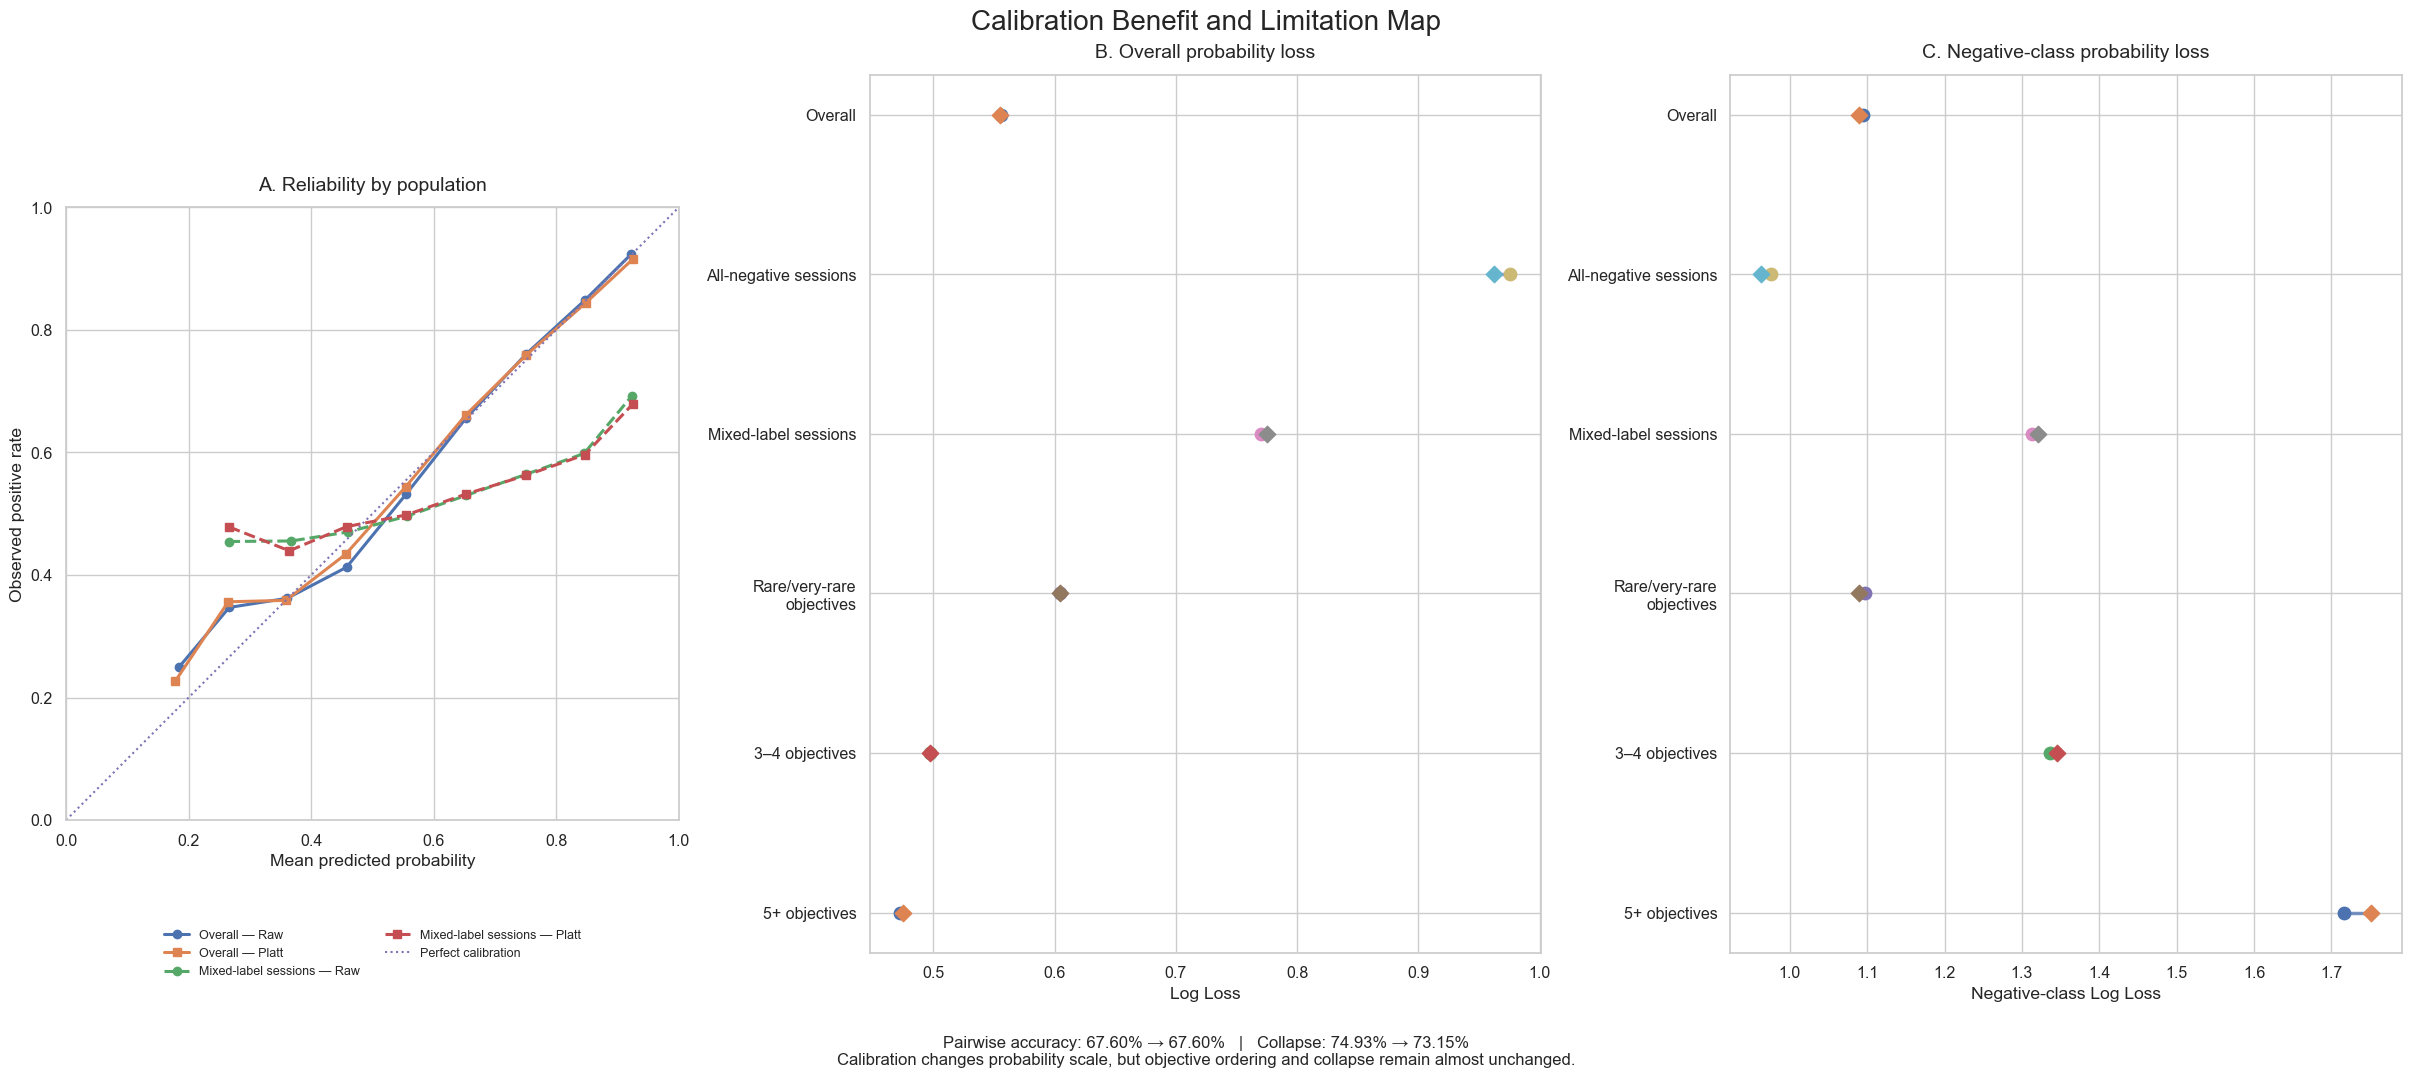

C:\Users\USER\AppData\Local\Temp\ipykernel_6524\4078801844.py:630: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  loss_annotations = loss_improvement.applymap(
C:\Users\USER\AppData\Local\Temp\ipykernel_6524\4078801844.py:704: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  disc_annotations = disc_improvement.applymap(


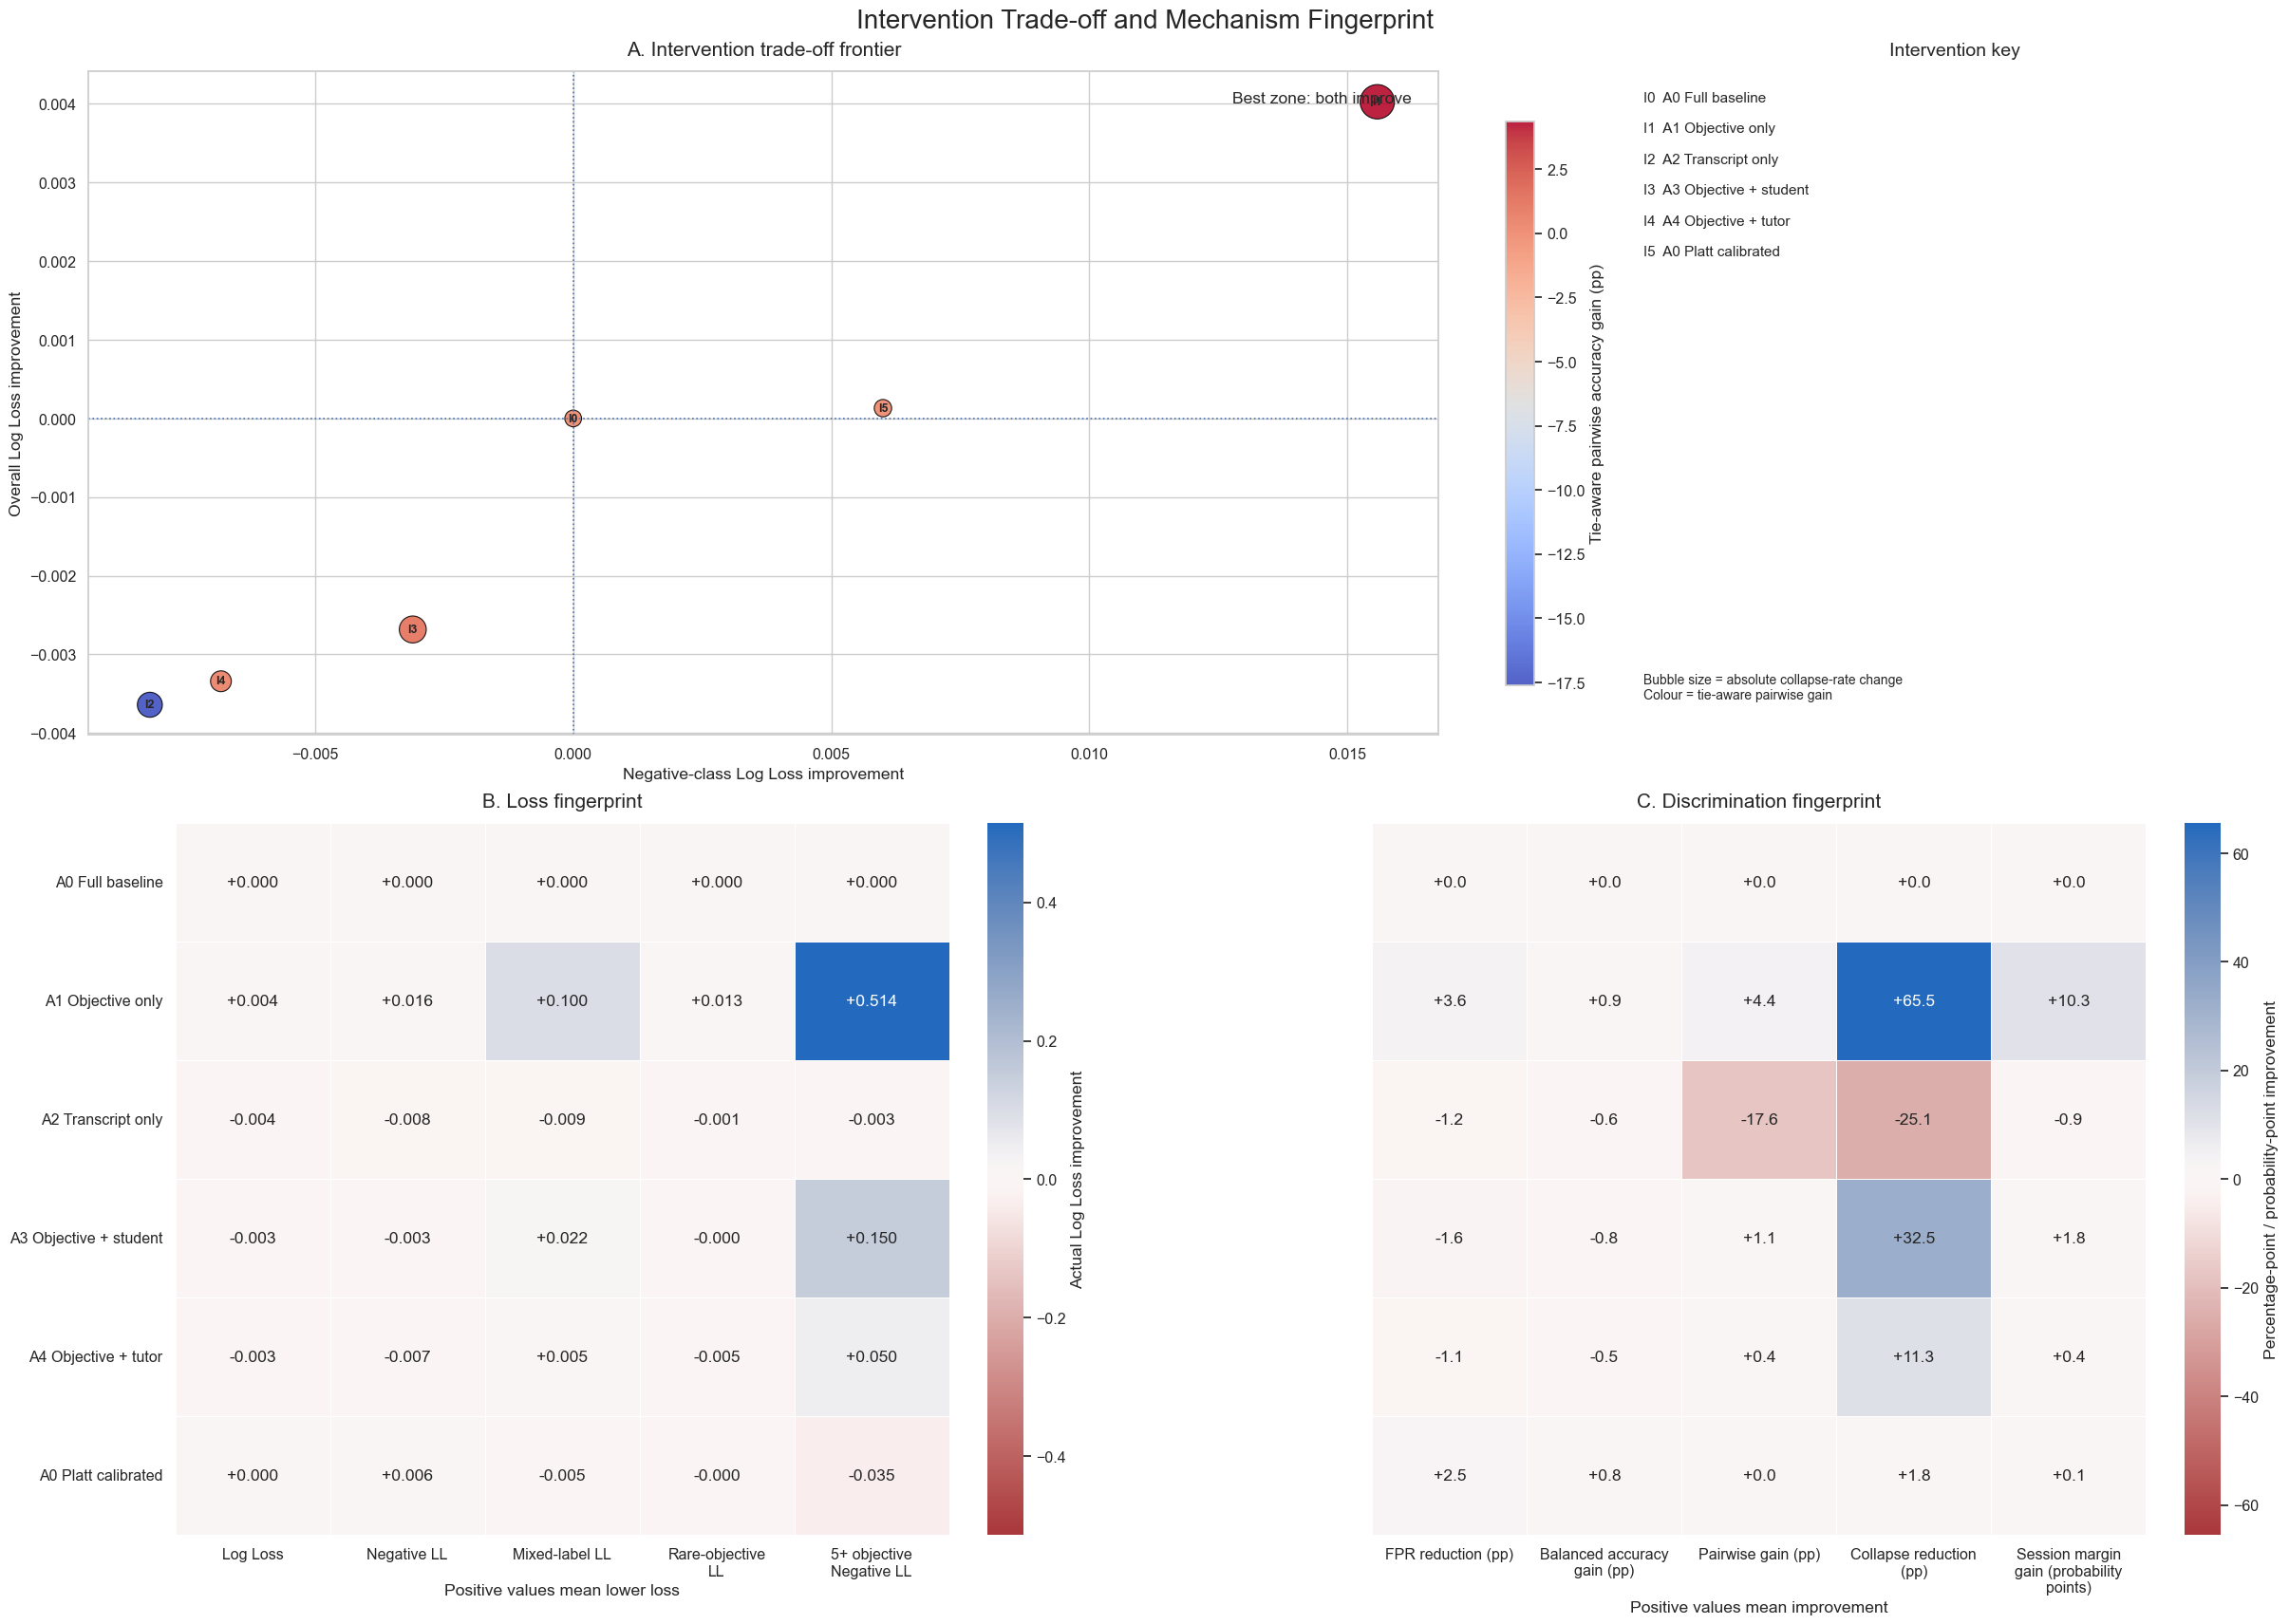

C:\Users\USER\AppData\Local\Temp\ipykernel_6524\4078801844.py:960: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_family.set_yticklabels([


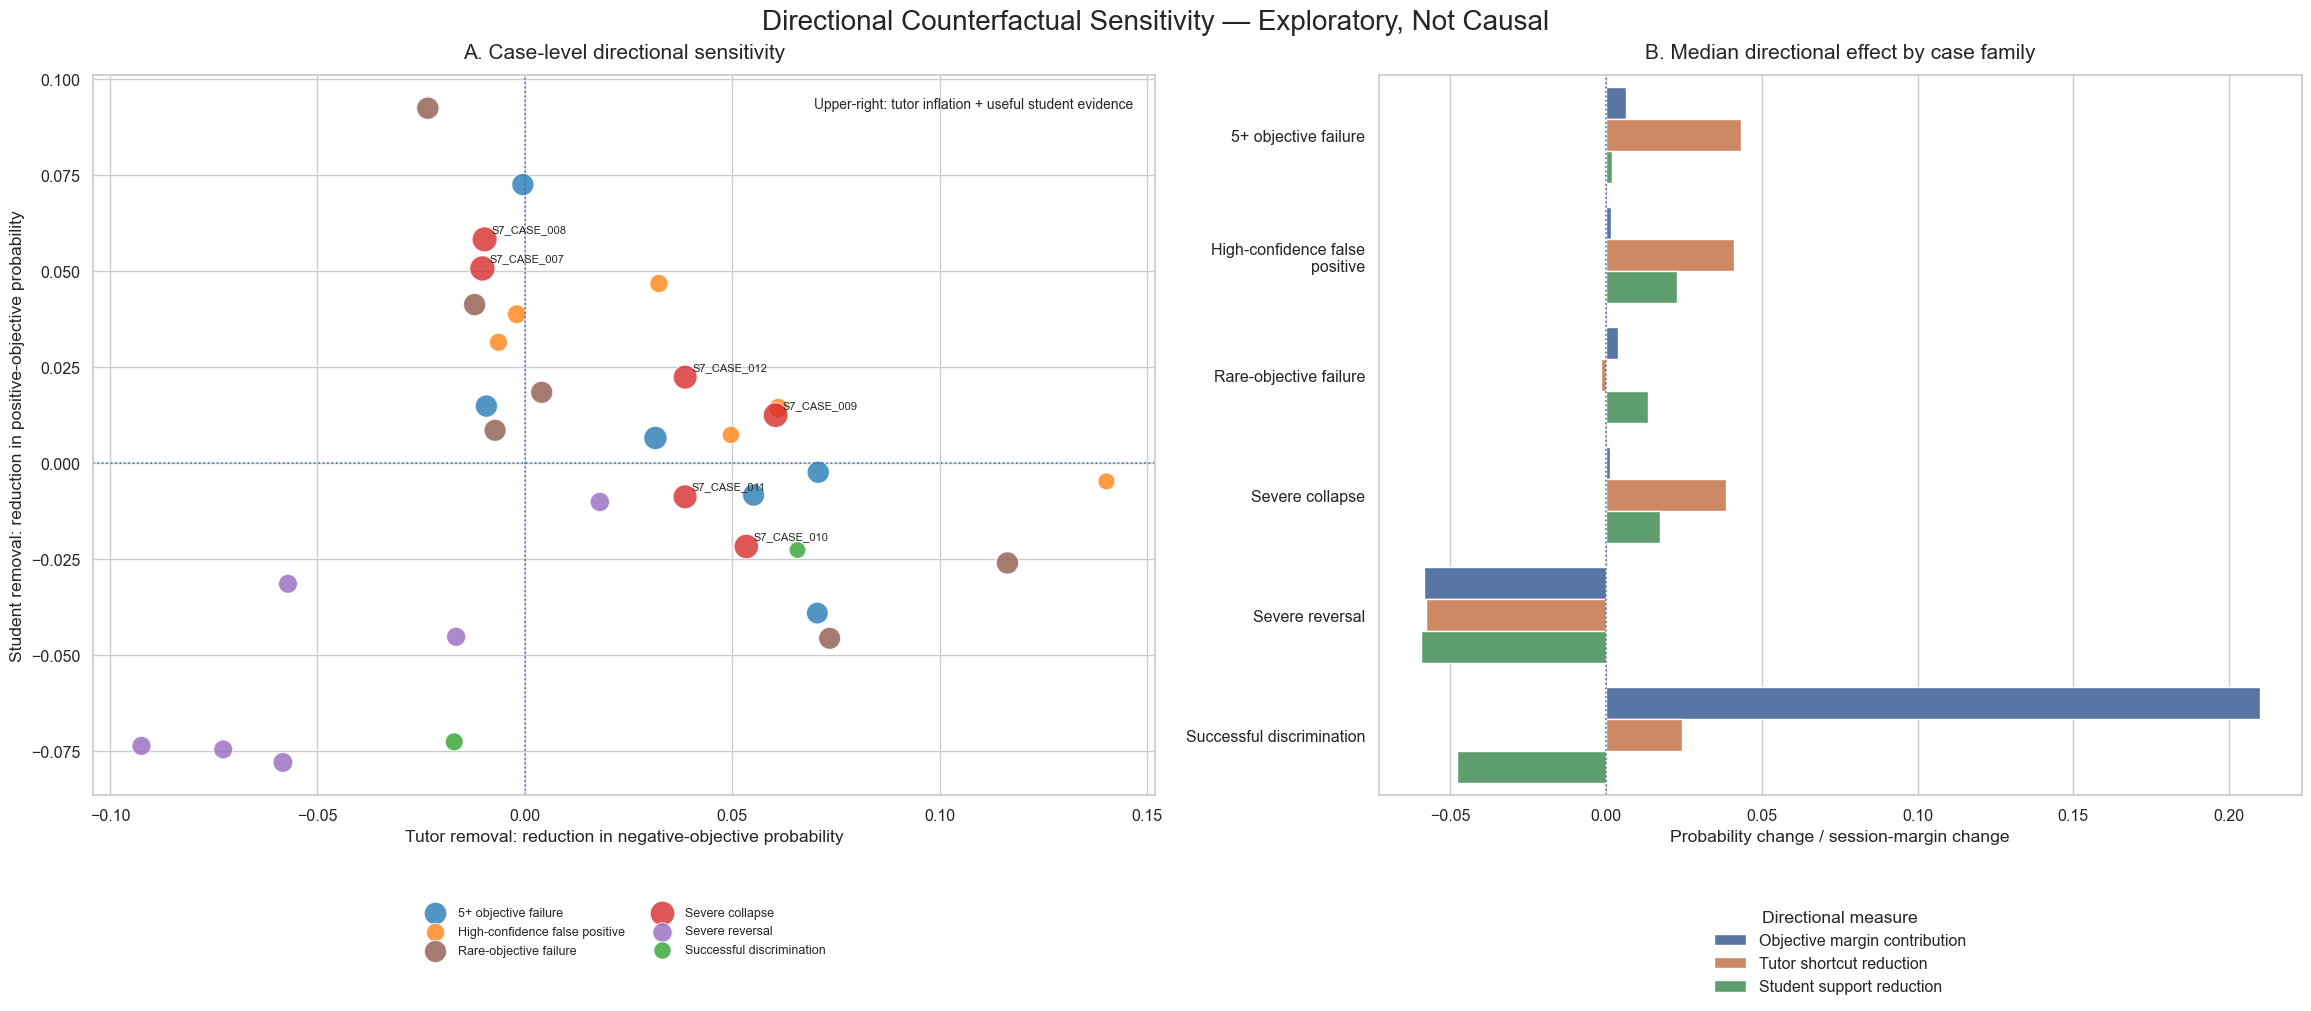

C:\Users\USER\AppData\Local\Temp\ipykernel_6524\4078801844.py:1019: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annotations = evidence_matrix.applymap(


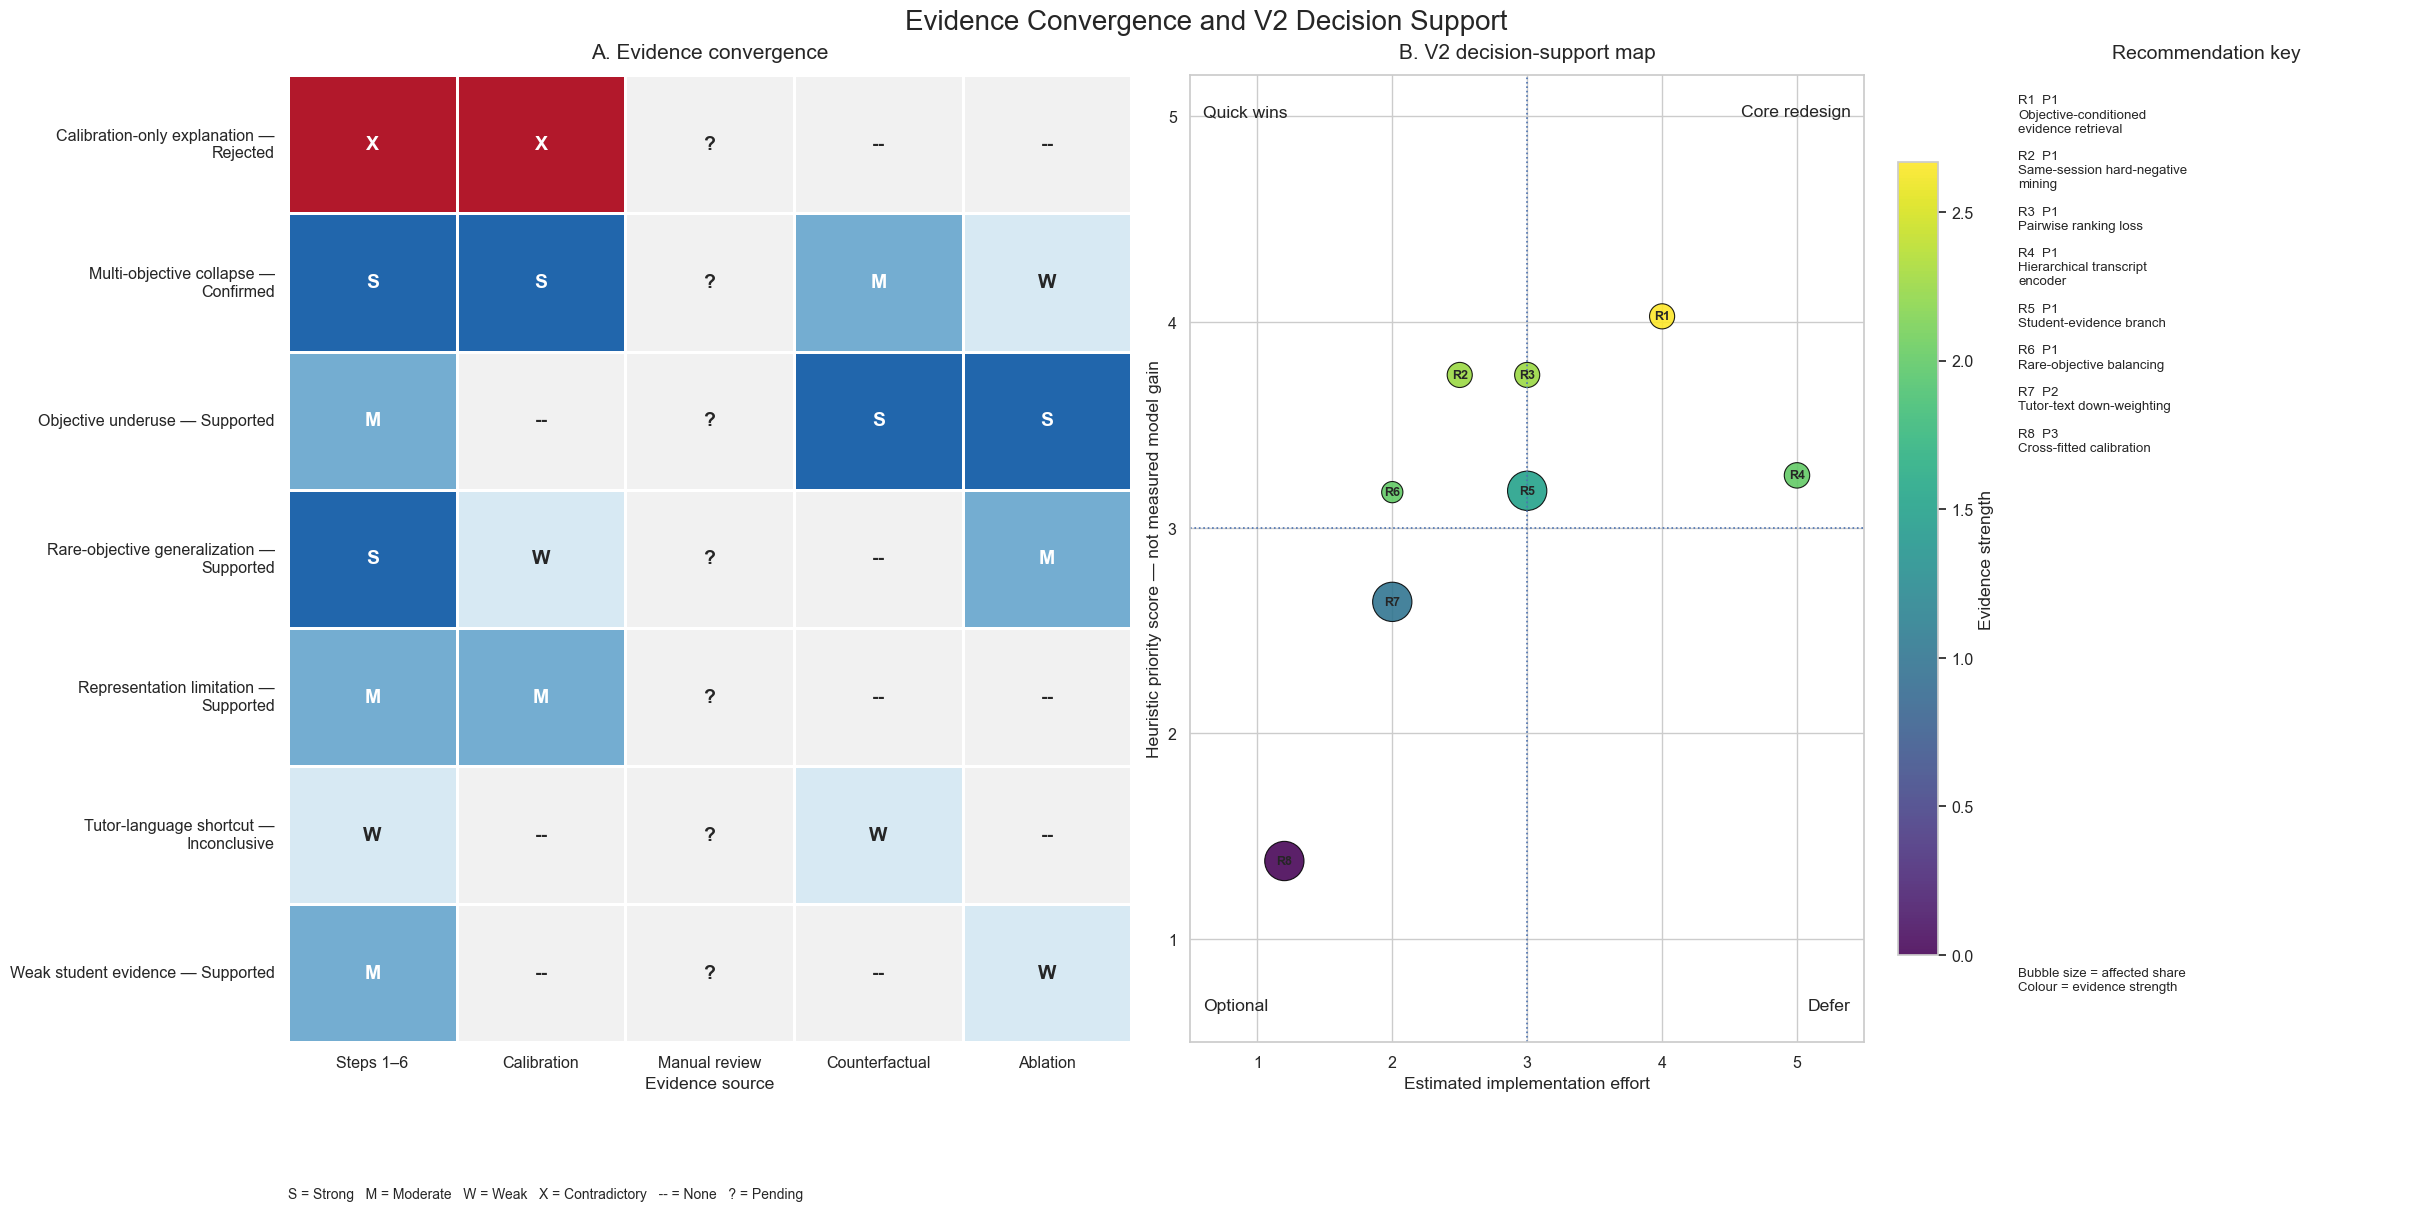

Corrected master figures saved:
C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Trace-The-Race-Competition\notebook\model_analysis\baselineanalysis_2\07_integrated_diagnostic_validation\04_synthesis\figures\calibration_benefit_limitation_map_corrected.png
C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Trace-The-Race-Competition\notebook\model_analysis\baselineanalysis_2\07_integrated_diagnostic_validation\04_synthesis\figures\intervention_tradeoff_fingerprint_corrected.png
C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Trace-The-Race-Competition\notebook\model_analysis\baselineanalysis_2\07_integrated_diagnostic_validation\04_synthesis\figures\directional_counterfactual_sensitivity_corrected.png
C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Trace-The-Race-Competition\notebook\model_analysis\baselineanalysis_2\07_integrated_diagnostic_validation\04_synthesis\figures\evidence_convergence_v2_decision_corrected.png


In [13]:
from pathlib import Path
import textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import BoundaryNorm, ListedColormap

sns.set_theme(
    style="whitegrid",
    context="notebook",
    font_scale=1.05
)


def wrap_text(value, width=22):
    return "\n".join(
        textwrap.wrap(str(value), width=width)
    )


def save_figure(fig, path):
    fig.savefig(
        path,
        dpi=300,
        bbox_inches="tight",
        facecolor="white"
    )

    plt.show()
    plt.close(fig)


def dumbbell(axis, table, value_column, title, xlabel):
    plot_data = table.copy().iloc[::-1]
    y = np.arange(len(plot_data))

    for index, (_, row) in enumerate(plot_data.iterrows()):
        axis.plot(
            [
                row[f"Raw {value_column}"],
                row[f"Platt {value_column}"]
            ],
            [index, index],
            linewidth=2.5,
            alpha=0.75
        )

        axis.scatter(
            row[f"Raw {value_column}"],
            index,
            s=80,
            marker="o",
            zorder=3
        )

        axis.scatter(
            row[f"Platt {value_column}"],
            index,
            s=70,
            marker="D",
            zorder=3
        )

    axis.set_yticks(y)

    axis.set_yticklabels([
        wrap_text(value, 24)
        for value in plot_data["Population"]
    ])

    axis.set_title(
        title,
        fontsize=14,
        pad=12
    )

    axis.set_xlabel(xlabel)
    axis.set_ylabel("")


figure_dir = (
    synthesis_results["output_dir"]
    / "figures"
)

figure_dir.mkdir(
    parents=True,
    exist_ok=True
)

saved_paths = []

# ============================================================
# FIGURE 1 — Calibration benefit versus limitation
# ============================================================

scorecard = calibration_results["scorecard"].copy()
reliability = calibration_results["reliability"].copy()

session_score = calibration_results[
    "session_scorecard"
].set_index("Prediction")

populations = [
    "Overall",
    "All-negative sessions",
    "Mixed-label sessions",
    "Rare/very-rare objectives",
    "3–4 objectives",
    "5+ objectives"
]

calibration_wide = []

for population in populations:
    group = scorecard[
        scorecard["Population"].eq(population)
    ].set_index("Prediction")

    if not {"Raw", "Platt"}.issubset(group.index):
        continue

    calibration_wide.append({
        "Population": population,
        "Raw Log Loss": group.loc["Raw", "Log Loss"],
        "Platt Log Loss": group.loc["Platt", "Log Loss"],
        "Raw Negative LL": group.loc["Raw", "Negative LL"],
        "Platt Negative LL": group.loc["Platt", "Negative LL"]
    })

calibration_wide = pd.DataFrame(
    calibration_wide
)

fig = plt.figure(
    figsize=(24, 10),
    constrained_layout=True
)

grid = fig.add_gridspec(
    1,
    3,
    width_ratios=[1.05, 1.15, 1.15]
)

ax_curve = fig.add_subplot(grid[0, 0])
ax_ll = fig.add_subplot(grid[0, 1])
ax_neg = fig.add_subplot(grid[0, 2])

for population, linestyle in [
    ("Overall", "-"),
    ("Mixed-label sessions", "--")
]:
    for prediction, marker in [
        ("Raw", "o"),
        ("Platt", "s")
    ]:
        curve = reliability[
            reliability["Population"].eq(population)
            & reliability["Prediction"].eq(prediction)
        ].sort_values("Mean_probability")

        if curve.empty:
            continue

        ax_curve.plot(
            curve["Mean_probability"],
            curve["Observed_positive_rate"],
            marker=marker,
            linestyle=linestyle,
            linewidth=2.2,
            markersize=6,
            label=f"{population} — {prediction}"
        )

ax_curve.plot(
    [0, 1],
    [0, 1],
    linestyle=":",
    linewidth=1.5,
    label="Perfect calibration"
)

ax_curve.set_title(
    "A. Reliability by population",
    fontsize=14,
    pad=12
)

ax_curve.set_xlabel(
    "Mean predicted probability"
)

ax_curve.set_ylabel(
    "Observed positive rate"
)

ax_curve.set_xlim(0, 1)
ax_curve.set_ylim(0, 1)

ax_curve.set_aspect(
    "equal",
    adjustable="box"
)

ax_curve.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.16),
    ncol=2,
    fontsize=9,
    frameon=False
)

dumbbell(
    ax_ll,
    calibration_wide,
    "Log Loss",
    "B. Overall probability loss",
    "Log Loss"
)

dumbbell(
    ax_neg,
    calibration_wide,
    "Negative LL",
    "C. Negative-class probability loss",
    "Negative-class Log Loss"
)

raw_pairwise = session_score.loc[
    "Raw",
    "Pairwise accuracy (%)"
]

platt_pairwise = session_score.loc[
    "Platt",
    "Pairwise accuracy (%)"
]

raw_collapse = session_score.loc[
    "Raw",
    "Collapse rate (%)"
]

platt_collapse = session_score.loc[
    "Platt",
    "Collapse rate (%)"
]

summary_note = (
    f"Pairwise accuracy: "
    f"{raw_pairwise:.2f}% → {platt_pairwise:.2f}%"
    f"   |   Collapse: "
    f"{raw_collapse:.2f}% → {platt_collapse:.2f}%\n"
    "Calibration changes probability scale, "
    "but objective ordering and collapse remain almost unchanged."
)

fig.text(
    0.5,
    -0.03,
    summary_note,
    ha="center",
    va="top",
    fontsize=12
)

fig.suptitle(
    "Calibration Benefit and Limitation Map",
    fontsize=20
)

path = (
    figure_dir
    / "calibration_benefit_limitation_map_corrected.png"
)

save_figure(fig, path)
saved_paths.append(path)

# ============================================================
# FIGURE 2 — Intervention trade-off and fingerprints
# ============================================================

ablation = ablation_results["metrics"].copy()

baseline = ablation[
    ablation["Variant"].eq("A0 Full baseline")
].iloc[0]

intervention = ablation.copy()

intervention["Overall LL improvement"] = (
    baseline["Log Loss"]
    - intervention["Log Loss"]
)

intervention["Negative LL improvement"] = (
    baseline["Negative LL"]
    - intervention["Negative LL"]
)

intervention["FPR reduction (pp)"] = (
    baseline["FPR (%)"]
    - intervention["FPR (%)"]
)

intervention["Balanced accuracy gain (pp)"] = (
    intervention["Balanced accuracy (%)"]
    - baseline["Balanced accuracy (%)"]
)

intervention["Pairwise gain (pp)"] = (
    intervention["Pairwise accuracy (%)"]
    - baseline["Pairwise accuracy (%)"]
)

intervention["Collapse reduction (pp)"] = (
    baseline["Collapse rate (%)"]
    - intervention["Collapse rate (%)"]
)

intervention[
    "Session margin gain (probability points)"
] = 100 * (
    intervention["Session margin"]
    - baseline["Session margin"]
)

platt_overall = scorecard[
    scorecard["Population"].eq("Overall")
].set_index("Prediction")

platt_groups = scorecard.set_index([
    "Population",
    "Prediction"
])

platt_row = baseline.copy()
platt_row["Variant"] = "A0 Platt calibrated"

platt_row["Log Loss"] = platt_overall.loc[
    "Platt",
    "Log Loss"
]

platt_row["Negative LL"] = platt_overall.loc[
    "Platt",
    "Negative LL"
]

platt_row["FPR (%)"] = platt_overall.loc[
    "Platt",
    "FPR (%)"
]

platt_row["Balanced accuracy (%)"] = (
    platt_overall.loc[
        "Platt",
        "Balanced accuracy (%)"
    ]
)

platt_row["Mixed-label LL"] = platt_groups.loc[
    ("Mixed-label sessions", "Platt"),
    "Log Loss"
]

platt_row["Rare-objective LL"] = platt_groups.loc[
    ("Rare/very-rare objectives", "Platt"),
    "Log Loss"
]

platt_row["5+ objective Negative LL"] = (
    platt_groups.loc[
        ("5+ objectives", "Platt"),
        "Negative LL"
    ]
)

platt_row["Pairwise accuracy (%)"] = (
    session_score.loc[
        "Platt",
        "Pairwise accuracy (%)"
    ]
)

platt_row["Session margin"] = session_score.loc[
    "Platt",
    "Session margin"
]

platt_row["Collapse rate (%)"] = session_score.loc[
    "Platt",
    "Collapse rate (%)"
]

platt_row["Overall LL improvement"] = (
    baseline["Log Loss"]
    - platt_row["Log Loss"]
)

platt_row["Negative LL improvement"] = (
    baseline["Negative LL"]
    - platt_row["Negative LL"]
)

platt_row["FPR reduction (pp)"] = (
    baseline["FPR (%)"]
    - platt_row["FPR (%)"]
)

platt_row["Balanced accuracy gain (pp)"] = (
    platt_row["Balanced accuracy (%)"]
    - baseline["Balanced accuracy (%)"]
)

platt_row["Pairwise gain (pp)"] = (
    platt_row["Pairwise accuracy (%)"]
    - baseline["Pairwise accuracy (%)"]
)

platt_row["Collapse reduction (pp)"] = (
    baseline["Collapse rate (%)"]
    - platt_row["Collapse rate (%)"]
)

platt_row[
    "Session margin gain (probability points)"
] = 100 * (
    platt_row["Session margin"]
    - baseline["Session margin"]
)

intervention = pd.concat(
    [
        intervention,
        pd.DataFrame([platt_row])
    ],
    ignore_index=True
)

intervention["Code"] = [
    f"I{index}"
    for index in range(len(intervention))
]

fig = plt.figure(
    figsize=(24, 17),
    constrained_layout=True
)

outer = fig.add_gridspec(
    2,
    2,
    height_ratios=[1, 1.25],
    width_ratios=[1.35, 0.65]
)

ax_frontier = fig.add_subplot(
    outer[0, 0]
)

ax_key = fig.add_subplot(
    outer[0, 1]
)

bottom = outer[1, :].subgridspec(
    1,
    2,
    wspace=0.25
)

ax_loss = fig.add_subplot(
    bottom[0, 0]
)

ax_disc = fig.add_subplot(
    bottom[0, 1]
)

ax_frontier.axhline(
    0,
    linestyle=":",
    linewidth=1.2
)

ax_frontier.axvline(
    0,
    linestyle=":",
    linewidth=1.2
)

size_base = intervention[
    "Collapse reduction (pp)"
].abs().max()

sizes = (
    160
    + 520
    * intervention[
        "Collapse reduction (pp)"
    ].abs()
    / (
        size_base
        if size_base > 0
        else 1
    )
)

scatter = ax_frontier.scatter(
    intervention["Negative LL improvement"],
    intervention["Overall LL improvement"],
    s=sizes,
    c=intervention["Pairwise gain (pp)"],
    cmap="coolwarm",
    edgecolors="black",
    linewidths=0.8,
    alpha=0.88
)

for _, row in intervention.iterrows():
    ax_frontier.text(
        row["Negative LL improvement"],
        row["Overall LL improvement"],
        row["Code"],
        ha="center",
        va="center",
        fontsize=9,
        fontweight="bold"
    )

ax_frontier.set_title(
    "A. Intervention trade-off frontier",
    fontsize=15,
    pad=12
)

ax_frontier.set_xlabel(
    "Negative-class Log Loss improvement"
)

ax_frontier.set_ylabel(
    "Overall Log Loss improvement"
)

ax_frontier.text(
    0.98,
    0.97,
    "Best zone: both improve",
    transform=ax_frontier.transAxes,
    ha="right",
    va="top"
)

fig.colorbar(
    scatter,
    ax=ax_frontier,
    label="Tie-aware pairwise accuracy gain (pp)",
    shrink=0.85
)

ax_key.axis("off")

key_lines = [
    f"{row['Code']}  "
    f"{wrap_text(row['Variant'], 30)}"
    for _, row in intervention.iterrows()
]

ax_key.set_title(
    "Intervention key",
    fontsize=14,
    pad=12
)

ax_key.text(
    0.02,
    0.97,
    "\n\n".join(key_lines),
    ha="left",
    va="top",
    fontsize=11
)

ax_key.text(
    0.02,
    0.05,
    "Bubble size = absolute collapse-rate change\n"
    "Colour = tie-aware pairwise gain",
    ha="left",
    va="bottom",
    fontsize=10
)

loss_columns = [
    "Log Loss",
    "Negative LL",
    "Mixed-label LL",
    "Rare-objective LL",
    "5+ objective Negative LL"
]

loss_improvement = pd.DataFrame(
    index=intervention["Variant"]
)

intervention_indexed = intervention.set_index(
    "Variant"
)

for metric in loss_columns:
    loss_improvement[metric] = (
        baseline[metric]
        - intervention_indexed[metric]
    )

loss_limit = max(
    float(
        np.nanmax(
            np.abs(
                loss_improvement.to_numpy()
            )
        )
    ),
    0.01
)

loss_annotations = loss_improvement.applymap(
    lambda value:
    f"{value:+.3f}"
    if pd.notna(value)
    else ""
)

sns.heatmap(
    loss_improvement,
    cmap="vlag_r",
    center=0,
    vmin=-loss_limit,
    vmax=loss_limit,
    annot=loss_annotations,
    fmt="",
    linewidths=0.7,
    linecolor="white",
    ax=ax_loss,
    cbar_kws={
        "label": "Actual Log Loss improvement"
    }
)

ax_loss.set_title(
    "B. Loss fingerprint",
    fontsize=15,
    pad=12
)

ax_loss.set_xlabel(
    "Positive values mean lower loss"
)

ax_loss.set_ylabel("")

ax_loss.set_xticklabels(
    [
        wrap_text(label.get_text(), 16)
        for label in ax_loss.get_xticklabels()
    ],
    rotation=0
)

ax_loss.set_yticklabels(
    [
        wrap_text(label.get_text(), 26)
        for label in ax_loss.get_yticklabels()
    ],
    rotation=0
)

disc_columns = [
    "FPR reduction (pp)",
    "Balanced accuracy gain (pp)",
    "Pairwise gain (pp)",
    "Collapse reduction (pp)",
    "Session margin gain (probability points)"
]

disc_improvement = intervention.set_index(
    "Variant"
)[disc_columns]

disc_limit = max(
    float(
        np.nanmax(
            np.abs(
                disc_improvement.to_numpy()
            )
        )
    ),
    1.0
)

disc_annotations = disc_improvement.applymap(
    lambda value:
    f"{value:+.1f}"
    if pd.notna(value)
    else ""
)

sns.heatmap(
    disc_improvement,
    cmap="vlag_r",
    center=0,
    vmin=-disc_limit,
    vmax=disc_limit,
    annot=disc_annotations,
    fmt="",
    linewidths=0.7,
    linecolor="white",
    ax=ax_disc,
    cbar_kws={
        "label": (
            "Percentage-point / "
            "probability-point improvement"
        )
    }
)

ax_disc.set_title(
    "C. Discrimination fingerprint",
    fontsize=15,
    pad=12
)

ax_disc.set_xlabel(
    "Positive values mean improvement"
)

ax_disc.set_ylabel("")

ax_disc.set_xticklabels(
    [
        wrap_text(label.get_text(), 18)
        for label in ax_disc.get_xticklabels()
    ],
    rotation=0
)

ax_disc.set_yticklabels([])

fig.suptitle(
    "Intervention Trade-off and Mechanism Fingerprint",
    fontsize=20
)

path = (
    figure_dir
    / "intervention_tradeoff_fingerprint_corrected.png"
)

save_figure(fig, path)
saved_paths.append(path)

# ============================================================
# FIGURE 3 — Directional counterfactual sensitivity
# ============================================================

cases = counterfactual_results[
    "case_summary"
].copy()

case_families = cases[
    "case_family"
].drop_duplicates().tolist()

palette = dict(
    zip(
        case_families,
        sns.color_palette(
            "tab10",
            n_colors=max(
                1,
                len(case_families)
            )
        )
    )
)

fig = plt.figure(
    figsize=(23, 10),
    constrained_layout=True
)

grid = fig.add_gridspec(
    1,
    2,
    width_ratios=[1.15, 1]
)

ax_case = fig.add_subplot(
    grid[0, 0]
)

ax_family = fig.add_subplot(
    grid[0, 1]
)

ax_case.axhline(
    0,
    linestyle=":",
    linewidth=1.2
)

ax_case.axvline(
    0,
    linestyle=":",
    linewidth=1.2
)

for family, group in cases.groupby(
    "case_family"
):
    sizes = (
        90
        + 260
        * group[
            "Original case Log Loss"
        ].clip(upper=2)
        / 2
    )

    ax_case.scatter(
        group["Tutor shortcut reduction"],
        group["Student support reduction"],
        s=sizes,
        color=palette[family],
        alpha=0.78,
        edgecolors="white",
        linewidths=0.8,
        label=family
    )

for _, row in cases.nlargest(
    min(6, len(cases)),
    "Original case Log Loss"
).iterrows():
    ax_case.annotate(
        row["case_id"],
        (
            row["Tutor shortcut reduction"],
            row["Student support reduction"]
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

ax_case.set_title(
    "A. Case-level directional sensitivity",
    fontsize=15,
    pad=12
)

ax_case.set_xlabel(
    "Tutor removal: reduction in "
    "negative-objective probability"
)

ax_case.set_ylabel(
    "Student removal: reduction in "
    "positive-objective probability"
)

ax_case.text(
    0.98,
    0.97,
    "Upper-right: tutor inflation "
    "+ useful student evidence",
    transform=ax_case.transAxes,
    ha="right",
    va="top",
    fontsize=10
)

ax_case.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.14),
    ncol=2,
    frameon=False,
    fontsize=9
)

family_summary = cases.groupby(
    "case_family"
).agg(
    Objective_margin_contribution=(
        "Objective margin contribution",
        "median"
    ),
    Tutor_shortcut_reduction=(
        "Tutor shortcut reduction",
        "median"
    ),
    Student_support_reduction=(
        "Student support reduction",
        "median"
    )
).reset_index()

family_long = family_summary.melt(
    id_vars="case_family",
    var_name="Measure",
    value_name="Median change"
)

measure_names = {
    "Objective_margin_contribution": (
        "Objective margin contribution"
    ),
    "Tutor_shortcut_reduction": (
        "Tutor shortcut reduction"
    ),
    "Student_support_reduction": (
        "Student support reduction"
    )
}

family_long["Measure"] = family_long[
    "Measure"
].map(measure_names)

sns.barplot(
    data=family_long,
    y="case_family",
    x="Median change",
    hue="Measure",
    ax=ax_family,
    orient="h"
)

ax_family.axvline(
    0,
    linestyle=":",
    linewidth=1.2
)

ax_family.set_title(
    "B. Median directional effect by case family",
    fontsize=15,
    pad=12
)

ax_family.set_xlabel(
    "Probability change / session-margin change"
)

ax_family.set_ylabel("")

ax_family.set_yticklabels([
    wrap_text(label.get_text(), 25)
    for label in ax_family.get_yticklabels()
])

ax_family.legend(
    title="Directional measure",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.14),
    ncol=1,
    frameon=False
)

fig.suptitle(
    "Directional Counterfactual Sensitivity — "
    "Exploratory, Not Causal",
    fontsize=20
)

path = (
    figure_dir
    / "directional_counterfactual_sensitivity_corrected.png"
)

save_figure(fig, path)
saved_paths.append(path)

# ============================================================
# FIGURE 4 — Evidence convergence and decision support
# ============================================================

evidence = synthesis_results["evidence"].copy()
verdicts = synthesis_results["verdicts"].copy()
priorities = synthesis_results["priorities"].copy()

evidence_order = [
    "Steps 1–6",
    "Calibration",
    "Manual review",
    "Counterfactual",
    "Ablation"
]

evidence_matrix = evidence.pivot(
    index="Hypothesis",
    columns="Evidence source",
    values="Evidence value"
).reindex(columns=evidence_order)

plot_matrix = evidence_matrix.fillna(0)

label_map = {
    3: "S",
    2: "M",
    1: "W",
    0: "--",
    -1: "X"
}

annotations = evidence_matrix.applymap(
    lambda value:
    "?"
    if pd.isna(value)
    else label_map.get(
        int(value),
        "--"
    )
)

colormap = ListedColormap([
    "#b2182b",
    "#f1f1f1",
    "#d7e9f3",
    "#74add1",
    "#2166ac"
])

norm = BoundaryNorm(
    [
        -1.5,
        -0.5,
        0.5,
        1.5,
        2.5,
        3.5
    ],
    colormap.N
)

verdict_lookup = verdicts.set_index(
    "Hypothesis"
)["Verdict"].to_dict()

priorities = priorities.copy()

priorities["Code"] = [
    f"R{index + 1}"
    for index in range(len(priorities))
]

fig = plt.figure(
    figsize=(24, 12),
    constrained_layout=True
)

grid = fig.add_gridspec(
    1,
    3,
    width_ratios=[1.25, 1, 0.58]
)

ax_evidence = fig.add_subplot(
    grid[0, 0]
)

ax_priority = fig.add_subplot(
    grid[0, 1]
)

ax_priority_key = fig.add_subplot(
    grid[0, 2]
)

sns.heatmap(
    plot_matrix,
    cmap=colormap,
    norm=norm,
    annot=annotations,
    fmt="",
    linewidths=1,
    linecolor="white",
    cbar=False,
    ax=ax_evidence,
    annot_kws={
        "fontsize": 14,
        "fontweight": "bold"
    }
)

ax_evidence.set_title(
    "A. Evidence convergence",
    fontsize=15,
    pad=12
)

ax_evidence.set_xlabel(
    "Evidence source"
)

ax_evidence.set_ylabel("")

ax_evidence.set_xticklabels(
    [
        wrap_text(label.get_text(), 16)
        for label in ax_evidence.get_xticklabels()
    ],
    rotation=0
)

ax_evidence.set_yticklabels(
    [
        wrap_text(
            f"{label.get_text()} — "
            f"{verdict_lookup.get(label.get_text(), 'Pending')}",
            34
        )
        for label in ax_evidence.get_yticklabels()
    ],
    rotation=0
)

ax_evidence.text(
    0,
    -0.15,
    "S = Strong   M = Moderate   W = Weak   "
    "X = Contradictory   -- = None   ? = Pending",
    transform=ax_evidence.transAxes,
    ha="left",
    va="top",
    fontsize=10
)

ax_priority.axvline(
    3,
    linestyle=":",
    linewidth=1.2
)

ax_priority.axhline(
    3,
    linestyle=":",
    linewidth=1.2
)

affected = priorities[
    "Affected share (%)"
].clip(lower=0)

sizes = (
    180
    + 620
    * affected
    / max(
        float(affected.max()),
        1
    )
)

scatter = ax_priority.scatter(
    priorities["Implementation effort"],
    priorities["Heuristic priority score"],
    s=sizes,
    c=priorities["Evidence strength"],
    cmap="viridis",
    edgecolors="black",
    linewidths=0.8,
    alpha=0.88
)

for _, row in priorities.iterrows():
    ax_priority.text(
        row["Implementation effort"],
        row["Heuristic priority score"],
        row["Code"],
        ha="center",
        va="center",
        fontsize=9,
        fontweight="bold"
    )

ax_priority.set_title(
    "B. V2 decision-support map",
    fontsize=15,
    pad=12
)

ax_priority.set_xlabel(
    "Estimated implementation effort"
)

ax_priority.set_ylabel(
    "Heuristic priority score — "
    "not measured model gain"
)

ax_priority.set_xlim(
    0.5,
    5.5
)

ax_priority.set_ylim(
    0.5,
    5.2
)

ax_priority.text(
    0.02,
    0.97,
    "Quick wins",
    transform=ax_priority.transAxes,
    ha="left",
    va="top"
)

ax_priority.text(
    0.98,
    0.97,
    "Core redesign",
    transform=ax_priority.transAxes,
    ha="right",
    va="top"
)

ax_priority.text(
    0.02,
    0.03,
    "Optional",
    transform=ax_priority.transAxes,
    ha="left",
    va="bottom"
)

ax_priority.text(
    0.98,
    0.03,
    "Defer",
    transform=ax_priority.transAxes,
    ha="right",
    va="bottom"
)

fig.colorbar(
    scatter,
    ax=ax_priority,
    label="Evidence strength",
    shrink=0.82
)

priority_key = "\n\n".join([
    f"{row['Code']}  {row['Priority']}\n"
    f"{wrap_text(row['Recommendation'], 27)}"
    for _, row in priorities.iterrows()
])

ax_priority_key.axis("off")

ax_priority_key.set_title(
    "Recommendation key",
    fontsize=14,
    pad=12
)

ax_priority_key.text(
    0.02,
    0.98,
    priority_key,
    ha="left",
    va="top",
    fontsize=9.5
)

ax_priority_key.text(
    0.02,
    0.05,
    "Bubble size = affected share\n"
    "Colour = evidence strength",
    ha="left",
    va="bottom",
    fontsize=9.5
)

fig.suptitle(
    "Evidence Convergence and V2 Decision Support",
    fontsize=20
)

path = (
    figure_dir
    / "evidence_convergence_v2_decision_corrected.png"
)

save_figure(fig, path)
saved_paths.append(path)

print("Corrected master figures saved:")

for path in saved_paths:
    print(path)